# Introdução

Comecei este projeto ao ser desafiado para aprender sobre **Workforce Management**: a terminologia, as métricas e a forma de raciocinar sobre uma operação de atendimento. Escolhi uma base pública de métricas de call center no [Kaggle](https://www.kaggle.com/datasets/antaesterlin/call-center-metrics) e analisei como exercício de estudo.

A primeira análise que realizei chegou a conclusões bem confiantes: apontava a distribuição desigual de volume entre os call centers como causa do baixo SLA e recomendava redistribuir os contatos. As hipóteses eram plausíveis, mas... nenhuma delas havia sido testada de verdade.

Ao aprofundar meu estudo de WFM, percebi que essas conclusões não sobreviviam a um teste estatístico real. Em vez de simplesmente apagar a versão anterior, decidi manter as duas lado a lado para mostrar a minha evolução :

| | |
|---|---|
| **Parte 1** | A análise original, com os gráficos, as leituras e as recomendações exatamente como as escrevi. Só a estrutura do código foi modernizada. |
| **Parte 2** | A revisão crítica. Cada afirmação da Parte 1 é submetida ao teste que deveria tê-la precedido, e as conclusões são refeitas a partir do resultado. |



## O que a Parte 2 responde

- Em que patamar está a aderência ao SLA, e a que distância da meta?
- O gap é explicado por alguma dimensão mensurável: call center, canal, motivo de contato, dia da semana?
- O desempenho operacional se traduz na experiência do cliente?
- Como a demanda se compõe, e onde estão as reais alavancas para reduzi-la?
- O que esta base **não** permite concluir, e qual dado seria necessário obter?


![WFM Analysis](https://images.unsplash.com/photo-1519389950473-47ba0277781c?auto=format&fit=crop&w=800&q=80)

# 1.0 Preparação dos Dados

Esta seção é compartilhada pelas duas partes: carrega a base, padroniza tipos, declara a convenção de aderência ao SLA e fixa a janela de análise.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

In [2]:


# Rótulos de período em português (independente do locale do sistema)
MESES_PT = {
    1: "Janeiro", 2: "Fevereiro", 3: "Março", 4: "Abril",
    5: "Maio", 6: "Junho", 7: "Julho", 8: "Agosto",
    9: "Setembro", 10: "Outubro", 11: "Novembro", 12: "Dezembro"
}

def periodo_pt(ts):
    """Formata um timestamp como 'Mês de AAAA'."""
    return f"{MESES_PT[ts.month]} de {ts.year}"

# =========================
# Padrão visual dos gráficos
# =========================

FONTE_PADRAO = "Fonte: Call Center Metrics (Kaggle)"


def periodo_janela():
    """Rótulo de período derivado da janela de análise definida na seção 1.2."""
    dias = (DATA_FIM - DATA_INICIO).days + 1
    return (f"Período: {periodo_pt(DATA_INICIO)} "
            f"({DATA_INICIO:%d/%m} a {DATA_FIM:%d/%m}, {dias} dias)")


def pct_br(valor, casas=1):
    """Formata percentual no padrão brasileiro (vírgula decimal)."""
    return f"{valor:.{casas}f}".replace(".", ",") + "%"


def num_br(valor, casas=2, sinal=False):
    """Formata número no padrão brasileiro (vírgula decimal)."""
    formato = f"{{:{'+' if sinal else ''}.{casas}f}}"
    return formato.format(valor).replace(".", ",")


def tabela_br(tabela, **kwargs):
    """Texto de um DataFrame com vírgula decimal (os dados não são alterados).

    Cada coluna numérica usa um número fixo de casas (o maior que ela contém),
    como o pandas faz por padrão.
    """
    tabela = tabela.copy()
    for col in tabela.select_dtypes("float").columns:
        casas = max((len(repr(float(v)).split(".")[1]) for v in tabela[col].dropna()), default=0)
        tabela[col] = tabela[col].map(
            lambda v: "" if pd.isna(v) else f"{v:.{casas}f}".replace(".", ",")
        )
    return tabela.to_string(**kwargs)


def estilo_executivo(ax, titulo, subtitulo, ylabel="", *,
                     xlabel="", grid_axis="y", eixo_data=False,
                     margem_direita=1.0, fonte=None, periodo=None,
                     eixos_extra=()):
    """Aplica o padrão visual do projeto a um eixo e finaliza o layout.

    Concentra em um só lugar as decisões visuais que antes eram repetidas em
    cada gráfico: bordas, grid, eixo de datas, título/subtítulo e metadados.

    """
    # bordas: mantém apenas esquerda e inferior.
    # Grid leve e sólido, sempre atrás dos dados — tracejado fica reservado
    # para linhas de limite (meta), que não devem competir com o grid.
    for eixo in (ax, *eixos_extra):
        eixo.spines["top"].set_visible(False)
        eixo.spines["right"].set_visible(False)
        eixo.grid(axis=grid_axis, linestyle="-", alpha=0.2)
        eixo.set_axisbelow(True)

    # eixo de datas com um tick por dia
    if eixo_data:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Título, subtítulo e metadados são posicionados em POLEGADAS a partir das
    # bordas da figura, não em fração da altura: assim o espaçamento entre eles
    # é o mesmo em um gráfico de 5 cm e em um painel de 30 cm de altura.
    fig = ax.get_figure()
    h = fig.get_figheight()

    plt.tight_layout(rect=[0, 0.72 / h, margem_direita, 1 - 0.75 / h])

    fig.text(0.01, 1 - 0.28 / h, titulo, va="top",
             fontsize=12, fontweight="bold")
    fig.text(0.01, 1 - 0.52 / h, subtitulo, va="top",
             fontsize=10, color="#444444")

    fig.text(0.01, 0.33 / h, fonte or FONTE_PADRAO, fontsize=9, color="#666666")
    fig.text(0.01, 0.09 / h, periodo or periodo_janela(), fontsize=9, color="#666666")

# Rótulos em português para exibição (os dados permanecem inalterados)
ROTULOS_PT = {
    # status de SLA
    "Below SLA": "Abaixo do SLA", "Within SLA": "Dentro do SLA", "Above SLA": "Acima do SLA",
    # sentimento
    "Very Negative": "Muito Negativo", "Negative": "Negativo", "Neutral": "Neutro",
    "Positive": "Positivo", "Very Positive": "Muito Positivo",
    # canal
    "Call-Center": "Call center", "Chatbot": "Chatbot", "Email": "E-mail", "Web": "Web",
    # motivo do contato
    "Billing Question": "Dúvida de fatura", "Payments": "Pagamentos",
    "Service Outage": "Indisponibilidade",
    # dias da semana
    "Monday": "Segunda", "Tuesday": "Terça", "Wednesday": "Quarta", "Thursday": "Quinta",
    "Friday": "Sexta", "Saturday": "Sábado", "Sunday": "Domingo",
}


def rotulo(chave):
    """Tradução para exibição, com o próprio valor como fallback."""
    return ROTULOS_PT.get(chave, chave)

In [3]:
df = pd.read_csv("call-center.csv") 

In [4]:
# Padronizar nomes de colunas antes da auditoria.
# O CSV traz "  Call_timestamp" com espaços à esquerda, por isso o .str.strip().
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [5]:
# Descarte justificado pela auditoria da seção 3.1: ambas as colunas têm
# 32.940 de 32.941 valores nulos (agregados herdados da fonte).
df = df.drop(columns=["avg_satisfaction_score", "avg_call_duration(min)"])

In [6]:
df["id"] = df["id"].astype("string")
df["customer_name"] = df["customer_name"].astype("string")

df = df.rename(columns={"response_time": "SLA"})


categorical_cols = [
    "sentiment", "reason", "city", "state",
    "channel", "call_center", "SLA"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")


df["csat_score"] = pd.to_numeric(df["csat_score"], errors="coerce")  # mantém float64
df["call_day"] = pd.to_numeric(df["call_day"], errors="coerce").astype("int64")

df["call_duration_in_minutes"] = pd.to_numeric(
    df["call_duration_in_minutes"], errors="coerce"
).astype("int64")


df["call_timestamp"] = pd.to_datetime(df["call_timestamp"], errors="coerce")


df = df.rename(columns={"call_duration_in_minutes": "aht"})

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32941 entries, 0 to 32940
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              32940 non-null  string        
 1   customer_name   32941 non-null  string        
 2   sentiment       32941 non-null  category      
 3   csat_score      12271 non-null  float64       
 4   call_timestamp  32941 non-null  datetime64[ns]
 5   call_day        32941 non-null  int64         
 6   reason          32941 non-null  category      
 7   city            32941 non-null  category      
 8   state           32941 non-null  category      
 9   channel         32941 non-null  category      
 10  SLA             32941 non-null  category      
 11  aht             32941 non-null  int64         
 12  call_center     32941 non-null  category      
dtypes: category(7), datetime64[ns](1), float64(1), int64(2), string(2)
memory usage: 1.8 MB


## 1.1 Convenção de aderência ao SLA

A coluna `SLA` assume três valores: `Within SLA`, `Below SLA` e `Above SLA`. A convenção adotada trata os rótulos como notas de desempenho: `Within` (atendeu) e `Above` (superou) contam como aderentes.

Essa escolha é registrada aqui como parâmetro do código. **A discussão sobre se ela é a leitura correta, e o quanto o resultado depende disso, está na seção 3.2.**

In [8]:
# A base não documenta o significado de "Above SLA" / "Below SLA".
# Convenção adotada: os rótulos expressam desempenho em relação ao esperado.
CATEGORIAS_ADERENTES = ["Within SLA", "Above SLA"]
META_SLA = 0.80

df["sla_ok"] = df["SLA"].isin(CATEGORIAS_ADERENTES)

print(f"Aderência sob a convenção adotada: {df['sla_ok'].mean() * 100:.1f}%".replace(".", ","))

Aderência sob a convenção adotada: 75,3%


## 1.2 Janela de análise

O último dia da base tem apenas 1 registro contra uma média de ~1.100/dia: é um dia incompleto e distorce qualquer série temporal.

A exclusão é definida **uma única vez aqui** e produz `df_analise` e as constantes `DATA_INICIO` / `DATA_FIM`, usadas por todos os gráficos das duas partes. O DataFrame de origem nunca é modificado, o que mantém a célula idempotente: reexecutá-la não corta mais dias.

In [9]:
# 1. Coluna de data (criada uma única vez)
df["date"] = df["call_timestamp"].dt.floor("D")

# 2. Exclusão do dia incompleto
volume_por_dia = df.groupby("date").size()
DIA_INCOMPLETO = volume_por_dia.index.max()

# df_analise é derivado: o df original permanece intacto e a célula é idempotente
df_analise = df[df["date"] < DIA_INCOMPLETO].copy()

DATA_INICIO = df_analise["date"].min()
DATA_FIM = df_analise["date"].max()

# 3. Registro da janela
print(f"Base completa : {len(df):,} registros | "
      f"{df['date'].min():%d/%m/%Y} a {df['date'].max():%d/%m/%Y}".replace(",", "."))
print(f"Dia excluído  : {DIA_INCOMPLETO:%d/%m/%Y} "
      f"({volume_por_dia.loc[DIA_INCOMPLETO]} registro vs média de "
      f"{volume_por_dia.iloc[:-1].mean():.0f}/dia)")
print(f"Janela        : {DATA_INICIO:%d/%m/%Y} a {DATA_FIM:%d/%m/%Y} | "
      f"{df_analise['date'].nunique()} dias | "
      f"{len(df_analise):,} registros".replace(",", "."))

Base completa : 32.941 registros | 01/10/2020 a 31/10/2020
Dia excluído  : 31/10/2020 (1 registro vs média de 1098/dia)
Janela        : 01/10/2020 a 30/10/2020 | 30 dias | 32.940 registros


# 2.0 Parte 1 — A primeira análise

> **O que segue é a análise original, preservada.** Os títulos dos gráficos, as leituras e as recomendações são exatamente os que escrevi na primeira versão, incluindo as afirmações que a Parte 2 vai derrubar. Apenas o código foi reescrito para usar a estrutura compartilhada.
>
> Ela é mantida aqui porque o contraste entre as duas partes é o ponto deste notebook, e porque uma análise descartada sem registro não ensina nada.

## 2.1 Sumário executivo

O desempenho do SLA durante outubro permaneceu consistentemente abaixo da meta de 80%, com apenas cerca de 62% das interações atendendo ao nível de serviço esperado.

Esse resultado não é explicado por incidentes isolados, mas por um desequilíbrio estrutural na forma como a demanda é distribuída entre os call centers.

O volume de chamadas concentra-se de forma persistente em determinadas localidades, gerando sobrecarga sustentada nos centros de alta demanda enquanto outros permanecem subutilizados.

Além disso, o sentimento do cliente aponta pontos recorrentes de atrito, especialmente relacionados a indisponibilidades de serviço, o que reforça o impacto operacional dessas ineficiências.

Endereçar a distribuição de demanda e ampliar a visibilidade sobre incidentes são as alavancas mais críticas para elevar o SLA e a experiência do cliente como um todo.

## 2.2 Desempenho atual do SLA

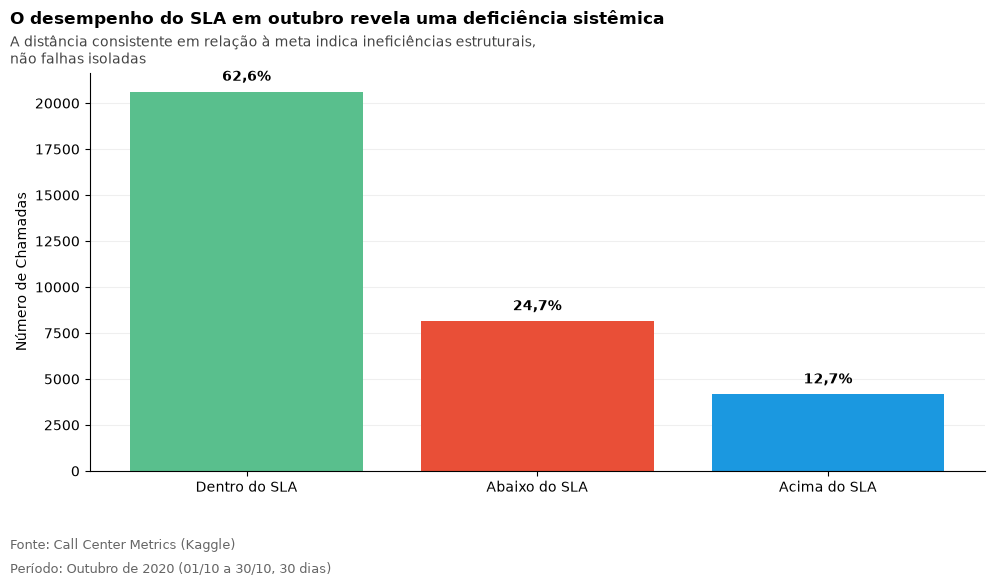

In [10]:

# 1. Preparação
sla_counts = df_analise["SLA"].value_counts()

# ordem lógica, depois do maior para o menor
order = ["Below SLA", "Within SLA", "Above SLA"]
sla_counts = sla_counts.reindex(order).dropna().sort_values(ascending=False)

sla_pct = sla_counts / sla_counts.sum() * 100

# 2. Gráfico
plt.figure(figsize=(10, 6))
ax = plt.gca()

colors = {
    "Below SLA": "#E94F37",   # vermelho (problema)
    "Within SLA": "#59BF8D",  # verde (ok)
    "Above SLA": "#1B98E0"    # azul (ótimo)
}

ax.bar(
    sla_counts.index,
    sla_counts.values,
    color=[colors[k] for k in sla_counts.index]
)

# rótulos diretos (apenas %)
for i, pct in enumerate(sla_pct.values):
    ax.text(
        i,
        sla_counts.values[i] + (sla_counts.max() * 0.02),
        pct_br(pct),
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_xticks(range(len(sla_counts.index)))
ax.set_xticklabels([rotulo(k) for k in sla_counts.index])

# 3. Padrão visual
estilo_executivo(
    ax,
    titulo="O desempenho do SLA em outubro revela uma deficiência sistêmica",
    subtitulo="A distância consistente em relação à meta indica ineficiências estruturais,\nnão falhas isoladas",
    ylabel="Número de Chamadas"
)

plt.show()

A aderência ao SLA durante outubro permaneceu consistentemente abaixo da meta de 80%, com aproximadamente 62% das interações dentro do SLA e quase 25% abaixo do esperado.

A distribuição é estável ao longo do período, indicando que o baixo desempenho não decorre de picos isolados, mas de um padrão operacional persistente.

Isso sugere que as estratégias atuais de capacidade e de gestão de demanda não são suficientes para absorver o volume de forma eficiente, resultando em uma lacuna sustentada de nível de serviço.

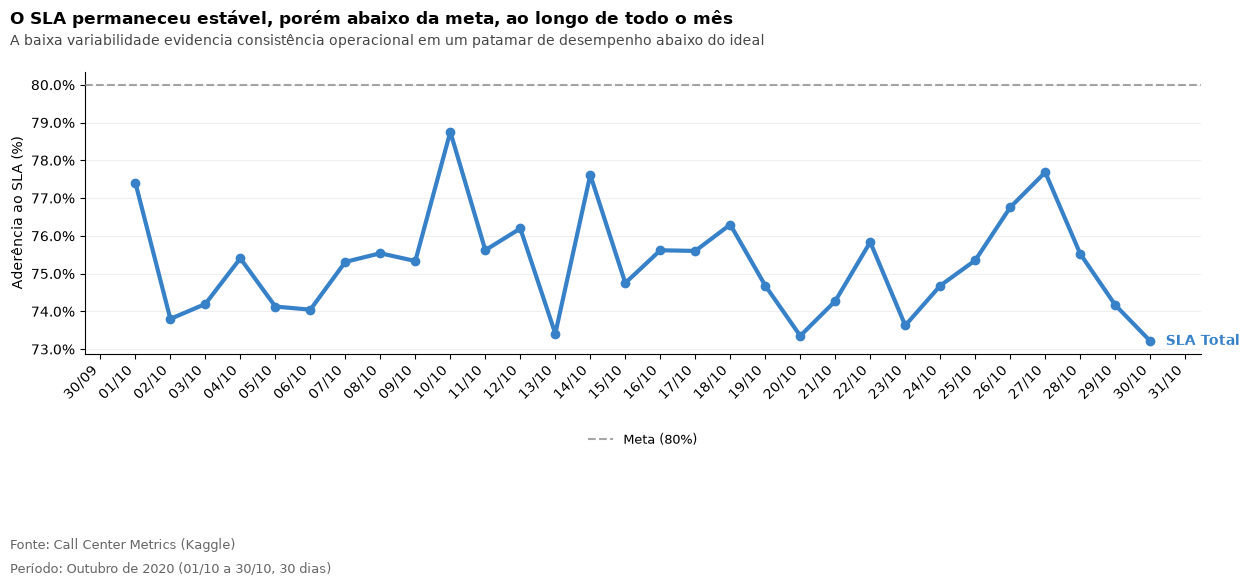

In [11]:
# 1. Preparação


# Janela (1.2) e regra de aderência (1.1) vêm prontas: nada é recalculado aqui
diario_sla = df_analise.groupby("date")["sla_ok"].agg(contatos="size", aderencia="mean")

# eixo temporal contínuo, ancorado na janela oficial
full_range = pd.date_range(start=DATA_INICIO, end=DATA_FIM, freq="D")
diario_sla = diario_sla.reindex(full_range)
diario_sla.index.name = "date"


# 2. Gráfico
plt.figure(figsize=(14, 6))
ax = plt.gca()

line, = ax.plot(
    diario_sla.index, diario_sla["aderencia"],
    color="#3781C8", marker="o", linewidth=3, zorder=4
)

linha_meta = ax.axhline(
    y=META_SLA, linestyle="--", color="gray", linewidth=1.5,
    alpha=0.7, zorder=3, label=f"Meta ({META_SLA:.0%})"
)

# rótulos diretos
x_margin = pd.Timedelta(days=0.3)
ax.text(diario_sla.index[-1] + x_margin, diario_sla["aderencia"].iloc[-1],
        " SLA Total", color=line.get_color(),
        va="center", fontsize=10, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.legend(handles=[linha_meta], loc="upper center",
          bbox_to_anchor=(0.5, -0.24), ncol=1, frameon=False, fontsize=9)


# 3. Padrão visual
estilo_executivo(
    ax,
    titulo="O SLA permaneceu estável, porém abaixo da meta, ao longo de todo o mês",
    subtitulo="A baixa variabilidade evidencia consistência operacional em um patamar de desempenho abaixo do ideal",
    ylabel="Aderência ao SLA (%)",
    eixo_data=True,
    margem_direita=0.90
)

plt.show()

O desempenho diário do SLA apresenta variabilidade limitada, mantendo-se dentro de uma faixa estreita ao longo de outubro.

Apesar dessa estabilidade, o resultado não alcança a meta definida em nenhum momento sustentado, o que reforça o caráter sistêmico do problema.

Esse padrão indica que a operação opera de forma consistente abaixo da eficiência de capacidade esperada, em vez de estar reagindo a interrupções pontuais.

## 2.3 Distribuição da demanda

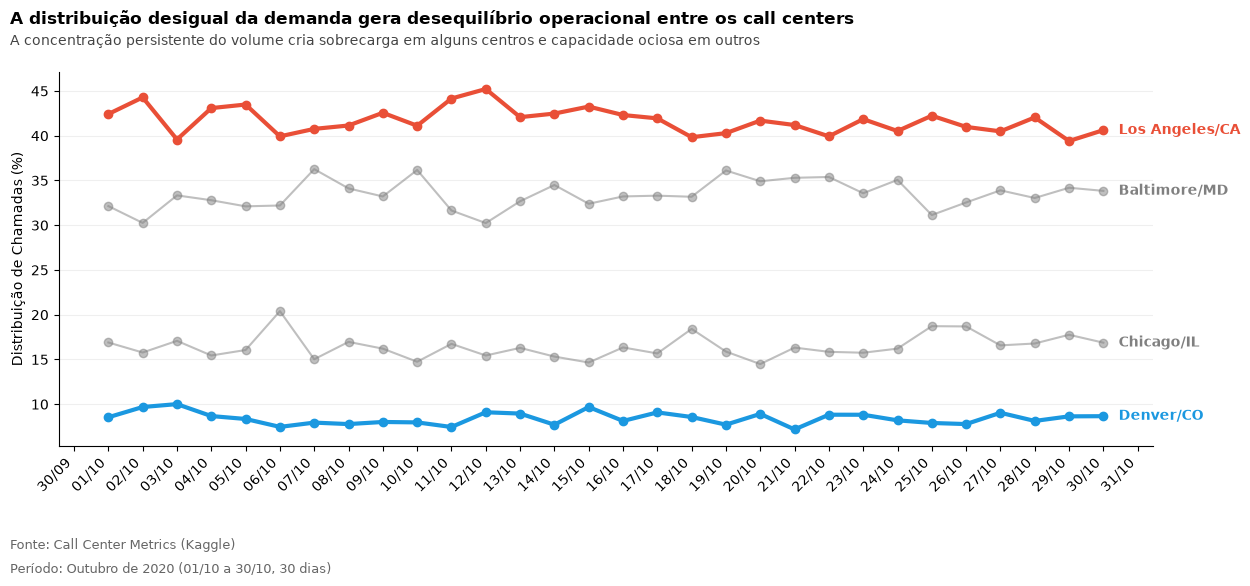

In [12]:
# 1. Preparação


# Pivot: percentual de chamadas por call_center e data, sobre a janela da seção 1.2
calls_pivot = (
    df_analise.groupby(["date", "call_center"], observed=True)
              .size()
              .unstack(fill_value=0)
)

# eixo temporal contínuo, ancorado na janela oficial
full_range = pd.date_range(start=DATA_INICIO, end=DATA_FIM, freq="D")
calls_pivot = calls_pivot.reindex(full_range, fill_value=0)
calls_pivot.index.name = "date"

# converter para percentual por dia
calls_pct = calls_pivot.div(calls_pivot.sum(axis=1), axis=0) * 100


# 2. Gráfico
plt.figure(figsize=(14, 6))
ax = plt.gca()

highlight_centers = {
    "Los Angeles/CA": "#E94F37",
    "Denver/CO": "#1B98E0"
}

x_margin = pd.Timedelta(days=0.3)

for col in calls_pct.columns:
    destaque = col in highlight_centers
    line, = ax.plot(
        calls_pct.index, calls_pct[col],
        marker="o",
        color=highlight_centers.get(col, "gray"),
        alpha=1.0 if destaque else 0.5,
        linewidth=3 if destaque else 1.5,
        zorder=3 if destaque else 2
    )
    # rótulo direto no último ponto (substitui a legenda)
    ax.text(
        calls_pct.index[-1] + x_margin, calls_pct[col].iloc[-1],
        f" {col}", color=line.get_color(),
        va="center", fontsize=10, fontweight="bold"
    )


# 3. Padrão visual


estilo_executivo(
    ax,
    titulo="A distribuição desigual da demanda gera desequilíbrio operacional entre os call centers",
    subtitulo="A concentração persistente do volume cria sobrecarga em alguns centros e capacidade ociosa em outros",
    ylabel="Distribuição de Chamadas (%)",
    eixo_data=True,
    margem_direita=0.90
)

plt.show()

O volume de chamadas em outubro foi distribuído de forma consistentemente desigual entre os call centers.

Los Angeles e Baltimore absorveram uma parcela desproporcionalmente alta das interações, enquanto centros como Denver permaneceram significativamente subutilizados.

Esse desequilíbrio persistiu durante todo o período, indicando que a distribuição da demanda não era ajustada dinamicamente conforme o volume.

Como consequência, os centros sobrecarregados enfrentaram pressão contínua, ampliando as quebras de SLA, enquanto a capacidade disponível em outras localidades permaneceu ociosa.

Essa ineficiência estrutural é o principal fator por trás do baixo desempenho de SLA observado no mês.

## 2.4 Direcionadores operacionais e experiência do cliente

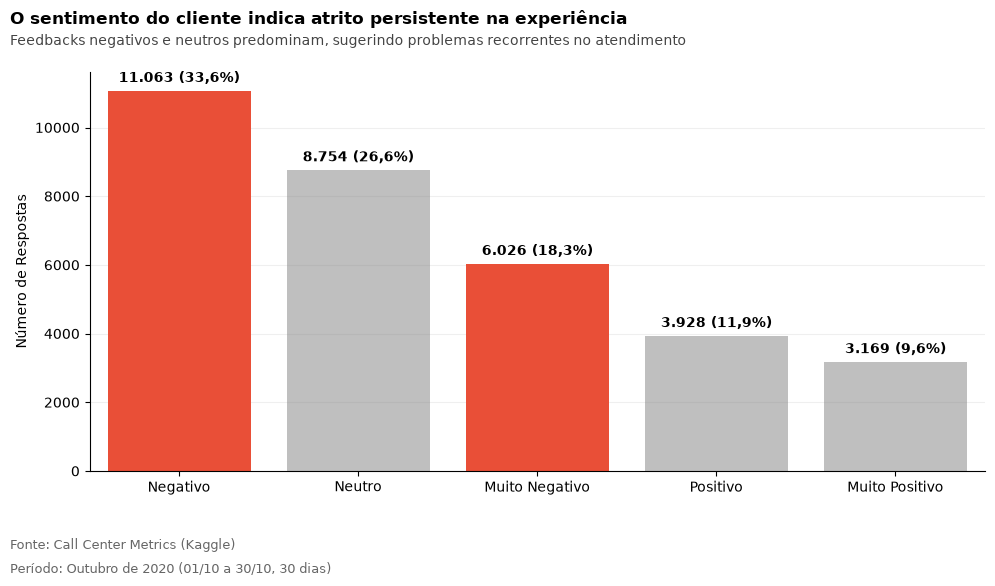

In [13]:
# 1. Preparação


sentiment_counts = df_analise["sentiment"].value_counts().sort_values(ascending=False)

total = sentiment_counts.sum()
percentages = sentiment_counts / total * 100


# 2. Gráfico
plt.figure(figsize=(10, 6))
ax = plt.gca()

# destacar os negativos
highlight = ["Very Negative", "Negative"]

bars = ax.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=["#E94F37" if c in highlight else "gray" for c in sentiment_counts.index],
    alpha=1.0
)

for bar, cat in zip(bars, sentiment_counts.index):
    if cat not in highlight:
        bar.set_alpha(0.5)

# rótulos com valor absoluto + %
for bar, pct in zip(bars, percentages.values):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + total * 0.005,
        f"{int(height):,}".replace(",", ".") + f" ({pct_br(pct)})",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_xticks(range(len(sentiment_counts.index)))
ax.set_xticklabels([rotulo(c) for c in sentiment_counts.index])
ax.set_xlim(-0.5, len(sentiment_counts) - 0.5)


# 3. Padrão visual
estilo_executivo(
    ax,
    titulo="O sentimento do cliente indica atrito persistente na experiência",
    subtitulo="Feedbacks negativos e neutros predominam, sugerindo problemas recorrentes no atendimento",
    ylabel="Número de Respostas"
)

plt.show()

O sentimento do cliente em outubro é predominantemente neutro a negativo, com uma parcela significativa das interações classificada como negativa ou muito negativa.

O sentimento positivo representa uma fatia menor, indicando que a maior parte das interações não entrega uma experiência forte.

Essa distribuição sugere a presença de atritos recorrentes no atendimento, possivelmente ligados a ineficiências operacionais e a problemas não resolvidos.

A consistência desse padrão reforça que a insatisfação do cliente não é episódica, mas está estruturalmente incorporada à experiência de serviço.

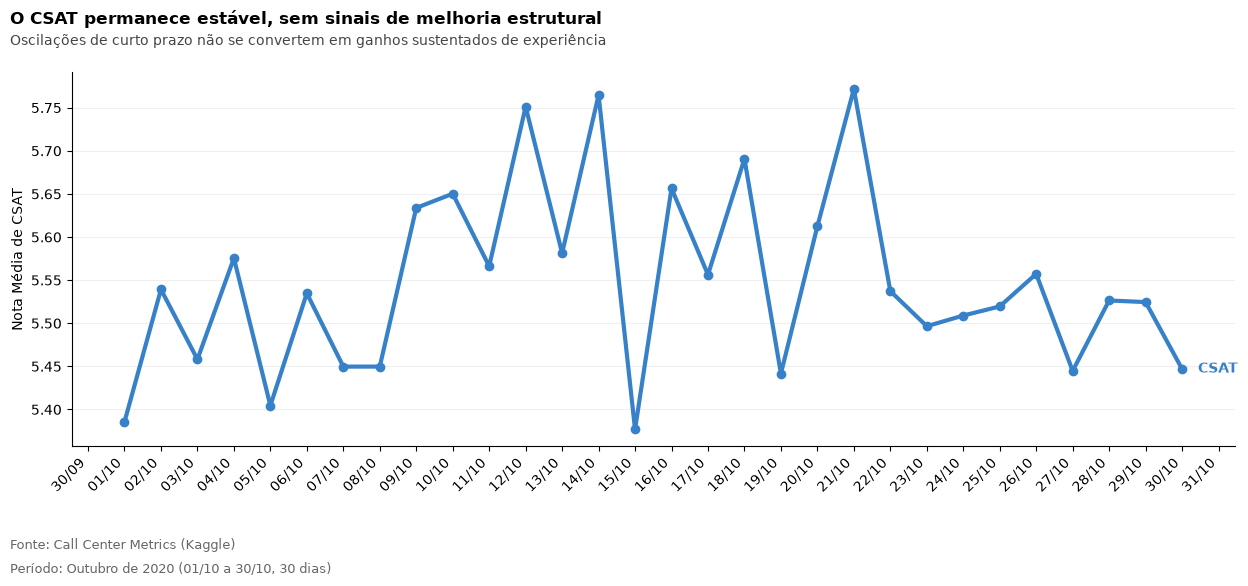

In [14]:
# 1. Preparação


# CSAT médio diário sobre a janela da seção 1.2.
# Atenção: .mean() ignora nulos -> esta é a média dos respondentes (cobertura de 37,3%,
# conforme auditoria da seção 3.1), não da base total.
csat_daily = (
    df_analise.groupby("date")["csat_score"]
    .mean()
    .sort_index()
)

# eixo temporal contínuo, ancorado na janela oficial
full_range = pd.date_range(start=DATA_INICIO, end=DATA_FIM, freq="D")
csat_daily = csat_daily.reindex(full_range)
csat_daily.index.name = "date"


# 2. Gráfico
plt.figure(figsize=(14, 6))
ax = plt.gca()

line, = ax.plot(
    csat_daily.index, csat_daily.values,
    marker="o", color="#3781C8", linewidth=3, zorder=3
)

# rótulo direto na linha (substitui a legenda)
x_margin = pd.Timedelta(days=0.3)
ax.text(
    csat_daily.index[-1] + x_margin, csat_daily.iloc[-1],
    " CSAT", color=line.get_color(),
    va="center", fontsize=10, fontweight="bold"
)


# 3. Padrão visual
estilo_executivo(
    ax,
    titulo="O CSAT permanece estável, sem sinais de melhoria estrutural",
    subtitulo="Oscilações de curto prazo não se convertem em ganhos sustentados de experiência",
    ylabel="Nota Média de CSAT",
    eixo_data=True,
    margem_direita=0.90
)

plt.show()

Os níveis de CSAT permanecem relativamente estáveis ao longo do mês, oscilando dentro de uma faixa estreita.

Embora ocorram picos pontuais, essas melhorias não se sustentam ao longo do tempo, o que indica ausência de ganhos estruturais na satisfação do cliente.

Isso sugere que, apesar de a operação manter uma experiência de base consistente, ela não endereça as causas-raiz necessárias para elevar de forma significativa a percepção do cliente.

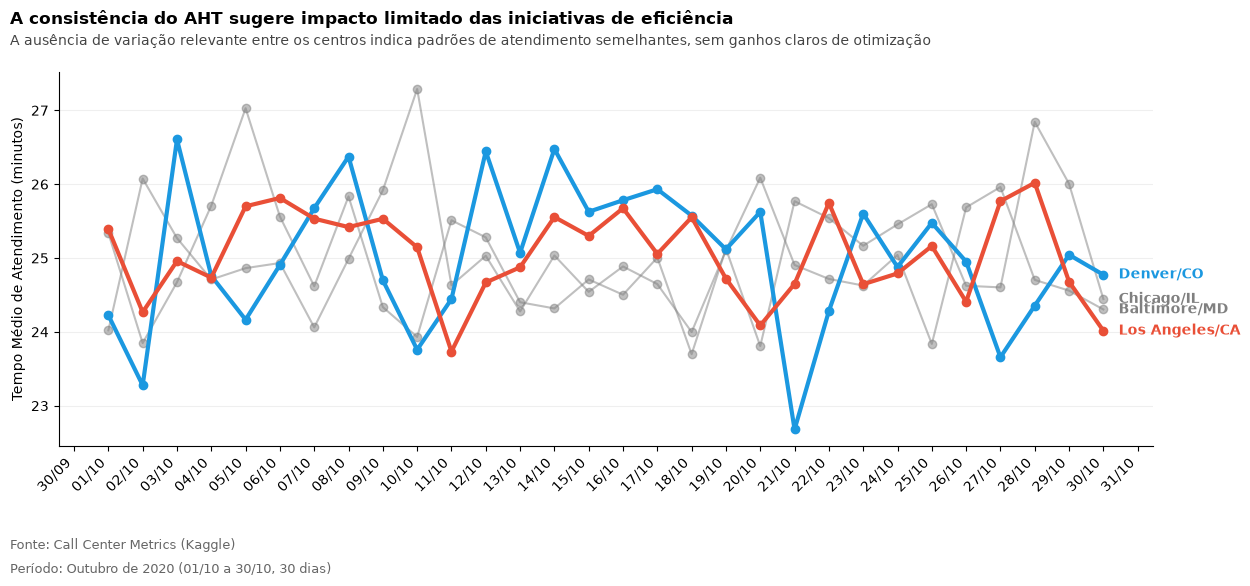

In [15]:
# =========================
# 1. Preparação
# =========================

# Média de AHT diário por call center, sobre a janela da seção 1.2
aht_mean_daily_callcenter = (
    df_analise.groupby(["date", "call_center"], observed=True)["aht"]
    .mean()
    .unstack("call_center")
    .sort_index()
)

# eixo temporal contínuo, ancorado na janela oficial
full_range = pd.date_range(start=DATA_INICIO, end=DATA_FIM, freq="D")
aht_mean_daily_callcenter = aht_mean_daily_callcenter.reindex(full_range)
aht_mean_daily_callcenter.index.name = "date"

# =========================
# 2. Gráfico
# =========================

plt.figure(figsize=(14, 6))
ax = plt.gca()

# mesmo destaque estratégico do gráfico de distribuição
highlight_centers = {
    "Los Angeles/CA": "#E94F37",
    "Denver/CO": "#1B98E0"
}

x_margin = pd.Timedelta(days=0.3)

for col in aht_mean_daily_callcenter.columns:
    destaque = col in highlight_centers
    line, = ax.plot(
        aht_mean_daily_callcenter.index,
        aht_mean_daily_callcenter[col],
        marker="o",
        color=highlight_centers.get(col, "gray"),
        alpha=1.0 if destaque else 0.5,
        linewidth=3 if destaque else 1.5,
        zorder=3 if destaque else 2
    )
    ax.text(
        aht_mean_daily_callcenter.index[-1] + x_margin,
        aht_mean_daily_callcenter[col].iloc[-1],
        f" {col}", color=line.get_color(),
        va="center", fontsize=10, fontweight="bold"
    )

# =========================
# 3. Padrão visual
# =========================

estilo_executivo(
    ax,
    titulo="A consistência do AHT sugere impacto limitado das iniciativas de eficiência",
    subtitulo="A ausência de variação relevante entre os centros indica padrões de atendimento semelhantes, sem ganhos claros de otimização",
    ylabel="Tempo Médio de Atendimento (minutos)",
    eixo_data=True,
    margem_direita=0.90
)

plt.show()

O Tempo Médio de Atendimento (AHT) mantém-se relativamente constante entre os call centers e ao longo do mês.

Não há desvios significativos que indiquem ganhos de eficiência ou problemas de desempenho em localidades específicas.

Se por um lado a estabilidade sugere controle operacional, por outro ela também aponta falta de otimização: nenhum centro demonstra eficiência superior que pudesse servir de referência (benchmark).

Isso reforça que a melhoria do SLA dependerá mais da distribuição da demanda do que da eficiência de atendimento isoladamente.

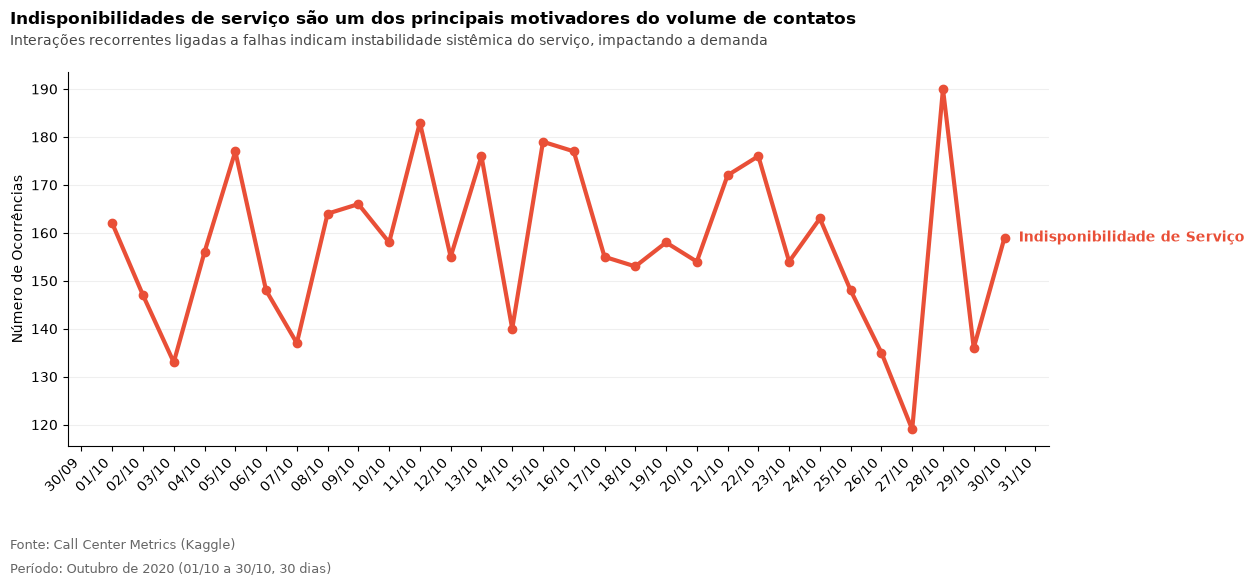

In [16]:
# =========================
# 1. Preparação
# =========================

# Ocorrências de indisponibilidade por dia, sobre a janela da seção 1.2.
# .size() em vez de ["id"].count(): há 1 id nulo na base (auditoria 3.1) e
# .count() ignoraria esse registro, subestimando o volume.
df_outage = df_analise[df_analise["reason"] == "Service Outage"]

outage_daily = (
    df_outage.groupby("date")
    .size()
    .sort_index()
)

# eixo temporal contínuo, ancorado na janela oficial
full_range = pd.date_range(start=DATA_INICIO, end=DATA_FIM, freq="D")
outage_daily = outage_daily.reindex(full_range, fill_value=0)
outage_daily.index.name = "date"

# =========================
# 2. Gráfico
# =========================

plt.figure(figsize=(14, 6))
ax = plt.gca()

line, = ax.plot(
    outage_daily.index, outage_daily.values,
    marker="o", color="#E94F37", linewidth=3, zorder=3
)

# rótulo direto na linha (substitui a legenda)
x_margin = pd.Timedelta(days=0.3)
ax.text(
    outage_daily.index[-1] + x_margin, outage_daily.iloc[-1],
    " Indisponibilidade de Serviço", color=line.get_color(),
    va="center", fontsize=10, fontweight="bold"
)

# =========================
# 3. Padrão visual
# =========================

estilo_executivo(
    ax,
    titulo="Indisponibilidades de serviço são um dos principais motivadores do volume de contatos",
    subtitulo="Interações recorrentes ligadas a falhas indicam instabilidade sistêmica do serviço, impactando a demanda",
    ylabel="Número de Ocorrências",
    eixo_data=True,
    margem_direita=0.90
)

plt.show()

## 2.5 Recomendações

Com base na análise de outubro de 2020, duas ações principais são recomendadas para endereçar o baixo desempenho de SLA e melhorar a eficiência operacional:

**1. Otimizar a distribuição da demanda entre os call centers**

- Redistribuir as interações recebidas de forma dinâmica, com base na capacidade e na demanda em tempo real.
- Reduzir a sobrecarga em centros de alto volume, como Los Angeles e Baltimore, direcionando chamadas para centros subutilizados, como Denver.

Isso equilibrará a pressão operacional, melhorará o aproveitamento dos recursos e elevará diretamente a aderência ao SLA.

**2. Fortalecer a visibilidade de incidentes e a colaboração com o time de SRE**

- O sentimento do cliente e os motivos de contato apontam problemas recorrentes de serviço, especialmente relacionados a indisponibilidades.
- Implementar um mecanismo estruturado de reporte para sinalizar picos em motivos específicos de contato (ex.: indisponibilidade de serviço) e notificar proativamente o time de SRE.

Isso permite investigação e resolução mais rápidas da causa-raiz, reduzindo contatos repetidos e melhorando tanto o SLA quanto a experiência do cliente.

# 3.0 Parte 2 — A revisão

## Por que voltei a esta análise?

A motivação para revisar a Parte 1 veio das aulas maravilhosas de **Fundamentos em Ciências de Dados** da professora [Cibele Russo](https://github.com/cibelerusso/FundamentosemCienciasdeDados). Lá, aprendi a diferença crucial entre **método**, **técnica** e **algoritmo**. Técnica e algoritmo são o *como* (o código, o gráfico, o `groupby`), enquanto o método é o procedimento sistemático que garante que a conclusão realmente decorre dos dados, e não das nossas próprias suposições!

A Parte 1 tinha técnica de sobra: Pandas, Matplotlib, métricas corretas. O que faltava era justamente o método. A Parte 1 induzia direto do gráfico para a causa: via um volume desigual entre call centers e logo concluía que havia sobrecarga, sem antes deduzir o que essa hipótese previa e testar.

É essa etapa dedutiva que a Parte 2 adiciona. Cada afirmação vira uma previsão testável antes de virar uma conclusão.

A Parte 1 afirma quatro coisas que **nunca** foram testadas:

1. Que a **concentração de volume** entre call centers causa o gap de SLA.
2. Que a **sobrecarga** dos centros de alto volume amplia as quebras de SLA.
3. Que o atrito na experiência do cliente está **ligado a ineficiências operacionais**.
4. Que **indisponibilidade de serviço** é um dos principais motivadores do volume de contatos.

São hipóteses razoáveis? Sim! Mas nenhuma vinha acompanhada do cruzamento de dados que a sustentaria ou derrubaria. Esta parte refaz o percurso da forma certa: primeiro verifica a base e a métrica, depois testa cada hipótese, e só então tira as conclusões.


## 3.1 Auditoria de qualidade dos dados

Na Parte 1, fizemos uma limpeza real na base: conversão de tipos, descarte de colunas e exclusão de dias incompletos. A maior parte dessas decisões estava certa, mas... faltou a **justificativa formal**!

Na versão original, nenhuma escolha veio acompanhada do número que a sustenta: o último dia, por exemplo, foi excluído sem mostrar que tinha apenas 1 registro contra uma média de ~1.100 por dia (esse número agora aparece já na seção 1.2, reescrita para esta versão). 

Nesta seção, vamos repetir as mesmas decisões da Parte 1, mas agora com o devido rigor analítico! Cada escolha será justificada com evidências, incluindo a cobertura de CSAT que não havia sido mencionada antes.


In [17]:
# =========================
# 1. Panorama geral
# =========================

print("=" * 72)
print(f"BASE PADRONIZADA (após a seção 1.0): {df.shape[0]:,} registros x {df.shape[1]} colunas".replace(",", "."))
print("=" * 72)

auditoria = pd.DataFrame({
    "tipo": df.dtypes.astype("string"),
    "nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(1),
    "valores_unicos": df.nunique(),
})
print(tabela_br(auditoria))

# As colunas agregadas já foram descartadas na seção 1.0:
# a checagem que justifica o descarte é feita sobre o CSV original.
bruto = pd.read_csv("call-center.csv")
print()
print("Colunas descartadas na seção 1.0 (contagem no CSV original):")
for coluna in ["Avg Satisfaction Score", "Avg Call Duration(min)"]:
    print(f"  {coluna}: {bruto[coluna].isna().sum():,} de {len(bruto):,} nulos".replace(",", "."))

# =========================
# 2. Duplicidades
# =========================

print()
print(f"IDs duplicados    : {df['id'].duplicated().sum()}")
print(f"Linhas duplicadas : {df.duplicated().sum()}")

# =========================
# 3. Cobertura temporal
# =========================

ts = pd.to_datetime(df["call_timestamp"], errors="coerce")
por_dia = ts.dt.date.value_counts().sort_index()

print()
print(f"Período: {ts.min():%d/%m/%Y} a {ts.max():%d/%m/%Y} ({por_dia.size} dias)")
print(f"Volume/dia (inclui o dia incompleto 31/10): média {por_dia.mean():.0f} | mín {por_dia.min()} | máx {por_dia.max()}")
print("Últimos 3 dias:", {str(k): int(v) for k, v in por_dia.tail(3).items()})

# =========================
# 4. Representatividade do CSAT (checagem de viés de não-resposta)
# =========================

cobertura = df["csat_score"].notna().mean() * 100

print()
print(f"COBERTURA DE CSAT: {df['csat_score'].notna().sum():,} de {len(df):,}".replace(",", ".")
      + f" ({pct_br(cobertura)})")

taxa_resposta = (
    df.groupby("sentiment", observed=True)["csat_score"]
      .agg(base="size", responderam="count")
      .assign(taxa_resposta_pct=lambda d: (d.responderam / d.base * 100).round(1))
)
print(tabela_br(taxa_resposta))

BASE PADRONIZADA (após a seção 1.0): 32.941 registros x 15 colunas
                          tipo  nulos %_nulos  valores_unicos
id                      string      1     0,0           32940
customer_name           string      0     0,0           32941
sentiment             category      0     0,0               5
csat_score             float64  20670    62,7              10
call_timestamp  datetime64[ns]      0     0,0              31
call_day                 int64      0     0,0              31
reason                category      0     0,0               3
city                  category      0     0,0             461
state                 category      0     0,0              51
channel               category      0     0,0               4
SLA                   category      0     0,0               3
aht                      int64      0     0,0              41
call_center           category      0     0,0               4
sla_ok                    bool      0     0,0               2
dat

**Achados e decisões**

| Achado | Impacto | Decisão |
|---|---|---|
| `csat_score` com **62,7% de nulos** (cobertura de 37,3%) | Toda média de CSAT reflete apenas quem respondeu, não a base total | Manter a métrica, mas **declarar a cobertura** em todo gráfico de CSAT |
| Taxa de resposta do CSAT **uniforme entre sentimentos** (36,3% a 38,0%) | Não há indício de que insatisfeitos respondam menos | **Viés de não-resposta baixo**: a média por respondentes é utilizável |
| `avg_satisfaction_score` e `avg_call_duration(min)` com 32.940 de 32.941 nulos | Colunas agregadas herdadas da fonte, sem valor analítico | **Descartar** (justificativa registrada aqui) |
| 1 registro com `id` nulo | Contagens via `["id"].count()` ignoram nulos e subestimam o volume | Usar `.size()` em vez de `.count()` nas contagens de volume |
| **31/10 com apenas 1 registro** (vs. média de ~1.100/dia) | Dia incompleto distorce qualquer série temporal | **Excluir** o último dia das análises diárias |
| Coluna `  Call_timestamp` com espaços à esquerda no CSV | Quebra o acesso por nome | Tratado pelo `.str.strip()` na padronização |
| Nenhuma linha ou `id` duplicado | — | Sem ação |

A base é **íntegra em granularidade de registro** (sem duplicidade, sem lacuna de dia). A única restrição relevante é a cobertura do CSAT, que passa a ser declarada explicitamente a partir daqui.

## 3.2 A métrica de aderência ao SLA está bem definida?

Toda a Parte 1 gira em torno de uma única métrica (**aderência ao SLA**) sem que ela jamais tenha sido definida. E a ausência de definição já aparece como inconsistência: a Parte 1 reporta **62%** no sumário executivo e plota **~75%** contra a meta no gráfico da série diária. São dois números diferentes para a mesma métrica, no mesmo documento.

A causa é que a coluna `SLA` tem três valores sem dicionário de dados, e a escolha de quais contam como aderentes nunca foi declarada.

In [18]:
# =========================
# 1. Sensibilidade às leituras possíveis
# =========================

dist = df["SLA"].value_counts(normalize=True) * 100

leituras = pd.DataFrame([
    ("Within + Above  (adotada)", dist["Within SLA"] + dist["Above SLA"],
     "os rótulos são notas de desempenho"),
    ("Within + Below", dist["Within SLA"] + dist["Below SLA"],
     "'Above' = tempo acima do limite = quebra"),
    ("Somente Within", dist["Within SLA"],
     "qualquer desvio conta como não aderente"),
], columns=["leitura", "aderencia_%", "premissa"])

leituras["vs_meta_pp"] = (leituras["aderencia_%"] - META_SLA * 100).round(1)
leituras["aderencia_%"] = leituras["aderencia_%"].round(1)

print("SENSIBILIDADE DA MÉTRICA À DEFINIÇÃO ADOTADA")
print(tabela_br(leituras, index=False))

print()
print(f"Aderência adotada: {pct_br(df['sla_ok'].mean() * 100)}  |  Meta: {META_SLA * 100:.0f}%  "
      f"|  Gap: {num_br((df['sla_ok'].mean() - META_SLA) * 100, 1, sinal=True)}pp")

SENSIBILIDADE DA MÉTRICA À DEFINIÇÃO ADOTADA
                  leitura aderencia_%                                 premissa vs_meta_pp
Within + Above  (adotada)        75,3       os rótulos são notas de desempenho       -4,7
           Within + Below        87,3 'Above' = tempo acima do limite = quebra        7,3
           Somente Within        62,6  qualquer desvio conta como não aderente      -17,4

Aderência adotada: 75,3%  |  Meta: 80%  |  Gap: -4,7pp


**Implicação.** A conclusão do projeto é sensível a essa convenção: sob a leitura alternativa (`Above` = tempo acima do limite = quebra), a aderência seria de 87,3% e a operação estaria **acima** da meta, e o diagnóstico se inverteria. Como a base não permite decidir, a convenção fica declarada aqui e a análise segue com **75,3%**, 4,7pp abaixo da meta de 80%.

**Nota sobre a unidade.** Diferenças entre dois percentuais aparecem, a partir daqui, sempre em **pontos percentuais (pp)**, nunca em "%". Dizer que a aderência "caiu 4,7%" seria ambíguo: poderia ser lido como uma queda relativa ao valor anterior (75,3% × 0,953 ≈ 71,8%, outra coisa). "4,7pp" é a subtração direta entre os dois percentuais (80% − 75,3%) e elimina essa ambiguidade: é a notação usada em todo o restante do notebook.

Todo cálculo de aderência daqui em diante usa a coluna `sla_ok`, nunca uma lista de categorias reescrita à mão.

## 3.3 A variação diária é real?

A Parte 1 descreve a série diária como tendo "variabilidade limitada" e conclui daí um "caráter sistêmico". A conclusão está certa, mas por um motivo que o gráfico não mostrava: **a variação exibida é quase toda ruído amostral**.

Cada ponto da série é uma estimativa a partir de ~1.100 contatos, não uma medida exata. Sem a margem desenhada, o leitor não tem como distinguir oscilação real de acaso, e a tendência natural é procurar explicação para picos que não existem.

Média do processo      : 75,3% (1098 contatos/dia em média)
Ruído típico de um dia : ±2,55pp (IC 95% da proporção diária)
Amplitude observada    : 73,2% a 78,8% (5,54pp)
Dias dentro da faixa   : 29 de 30
Gap até a meta         : 4,74pp — 1,9x maior que o ruído diário


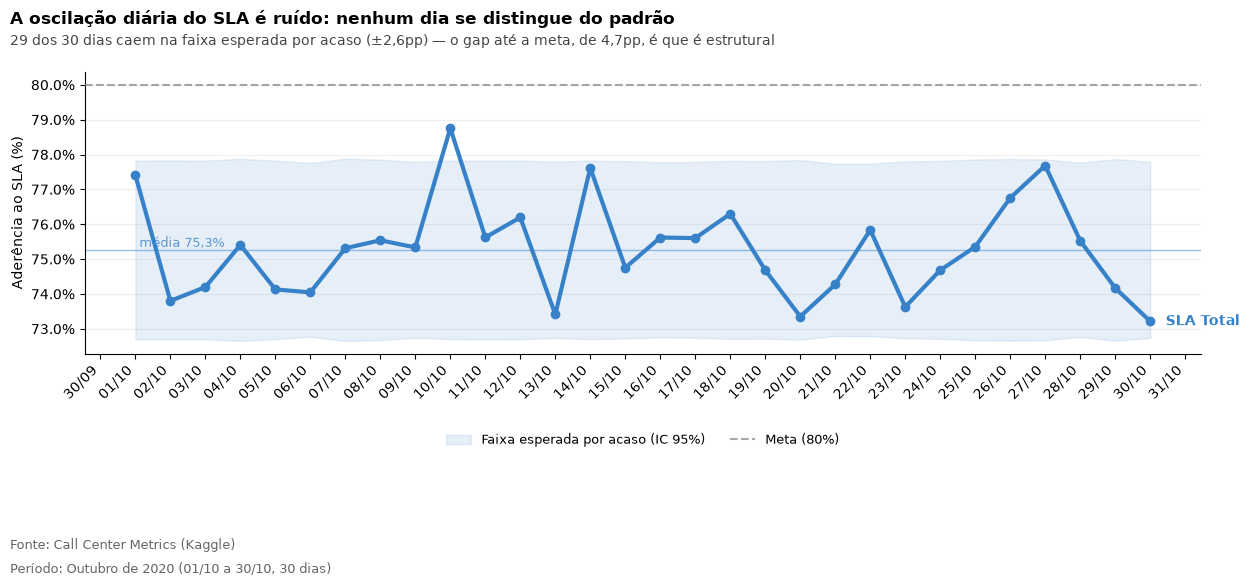

In [19]:
# =========================
# 1. Preparação
# =========================

# Janela (1.2) e regra de aderência (1.1) vêm prontas: nada é recalculado aqui
diario_sla = df_analise.groupby("date")["sla_ok"].agg(contatos="size", aderencia="mean")

# eixo temporal contínuo, ancorado na janela oficial
full_range = pd.date_range(start=DATA_INICIO, end=DATA_FIM, freq="D")
diario_sla = diario_sla.reindex(full_range)
diario_sla.index.name = "date"

# =========================
# 2. Faixa esperada por acaso
# =========================

# Cada ponto diário é uma estimativa a partir de ~1.100 contatos, não um valor
# exato. O erro padrão da proporção diz quanto o resultado de um dia pode variar
# sem que nada tenha mudado na operação.
sla_medio = df_analise["sla_ok"].mean()

erro_padrao = np.sqrt(sla_medio * (1 - sla_medio) / diario_sla["contatos"])
faixa_inferior = sla_medio - 1.96 * erro_padrao
faixa_superior = sla_medio + 1.96 * erro_padrao

dentro = ((diario_sla["aderencia"] >= faixa_inferior) &
          (diario_sla["aderencia"] <= faixa_superior)).sum()
dias_validos = diario_sla["aderencia"].notna().sum()

def pp(valor, casas=2):
    """Pontos percentuais no padrão brasileiro."""
    return f"{valor:.{casas}f}".replace(".", ",") + "pp"


ruido = 1.96 * erro_padrao.mean() * 100
amplitude = (diario_sla["aderencia"].max() - diario_sla["aderencia"].min()) * 100
gap = (META_SLA - sla_medio) * 100

print(f"Média do processo      : {pct_br(sla_medio * 100)} "
      f"({int(diario_sla['contatos'].mean())} contatos/dia em média)")
print(f"Ruído típico de um dia : ±{pp(ruido)} (IC 95% da proporção diária)")
print(f"Amplitude observada    : {pct_br(diario_sla['aderencia'].min() * 100)} a "
      f"{pct_br(diario_sla['aderencia'].max() * 100)} ({pp(amplitude)})")
print(f"Dias dentro da faixa   : {dentro} de {dias_validos}")
razao = f"{gap / ruido:.1f}".replace(".", ",")
print(f"Gap até a meta         : {pp(gap)} — {razao}x maior que o ruído diário")

# =========================
# 3. Gráfico
# =========================

plt.figure(figsize=(14, 6))
ax = plt.gca()

# faixa esperada por acaso (desenhada primeiro, ao fundo)
ax.fill_between(
    diario_sla.index, faixa_inferior, faixa_superior,
    color="#3781C8", alpha=0.12, zorder=1,
    label="Faixa esperada por acaso (IC 95%)"
)
ax.axhline(sla_medio, color="#3781C8", linewidth=1, alpha=0.5, zorder=2)

line, = ax.plot(
    diario_sla.index, diario_sla["aderencia"],
    color="#3781C8", marker="o", linewidth=3, zorder=4
)

linha_meta = ax.axhline(
    y=META_SLA, linestyle="--", color="gray", linewidth=1.5,
    alpha=0.7, zorder=3, label=f"Meta ({META_SLA:.0%})"
)

# rótulos diretos
x_margin = pd.Timedelta(days=0.3)
ax.text(diario_sla.index[-1] + x_margin, diario_sla["aderencia"].iloc[-1],
        " SLA Total", color=line.get_color(),
        va="center", fontsize=10, fontweight="bold")
ax.text(diario_sla.index[0], sla_medio, f" média {pct_br(sla_medio * 100)}",
        color="#3781C8", alpha=0.8, va="bottom", ha="left", fontsize=9)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles, labels_leg, loc="upper center", bbox_to_anchor=(0.5, -0.24),
          ncol=2, frameon=False, fontsize=9)

# =========================
# 4. Padrão visual
# =========================

estilo_executivo(
    ax,
    titulo="A oscilação diária do SLA é ruído: nenhum dia se distingue do padrão",
    subtitulo=(f"{dentro} dos {dias_validos} dias caem na faixa esperada por acaso (±{pp(ruido, 1)}) — "
               f"o gap até a meta, de {pp(gap, 1)}, é que é estrutural"),
    ylabel="Aderência ao SLA (%)",
    eixo_data=True,
    margem_direita=0.90
)

plt.show()

**A variação diária não é sinal, é ruído amostral.** Cada ponto da série é uma estimativa construída a partir de ~1.100 contatos, não uma medida exata: mesmo que a operação estivesse rigorosamente constante, o resultado de cada dia oscilaria em torno de ±2,6pp só por efeito de amostragem.

A faixa sombreada mostra essa margem. **29 dos 30 dias caem dentro dela**, e o único ponto fora (10/10, com 78,8%) é esperado: testando 30 dias a 95% de confiança, aproximadamente 1,5 falso positivo por acaso é o resultado normal. Pelos limites de controle de ±3 erros padrão, os 30 dias estão dentro.

Isso desqualifica um tipo comum de leitura: comparar o melhor dia (10/10, 78,8%) com o pior (30/10, 73,2%) e procurar o que "aconteceu" entre eles. Comparados isoladamente, os dois parecem diferentes, mas não foram escolhidos ao acaso: são os extremos de 30 dias. Só por amostragem, a distância esperada entre o maior e o menor de 30 dias é de cerca de 5,3pp, praticamente a observada (5,5pp). A comparação correta é de cada dia contra a faixa do processo, não de um dia contra outro, e por ela nenhum dia se destaca.

**O que é real é o patamar.** O gap de 4,7pp entre a média do processo e a meta é **1,9 vez maior** que o ruído diário e persiste em todos os 30 dias. É a esse nível, não às oscilações do dia a dia, que qualquer ação precisa responder.

## 3.4 O que a demanda realmente é

Antes de testar para onde a demanda vai, precisamos entender **o que ela é**. Na Parte 1, pulei essa etapa e acabei chamando todo o volume de "chamadas", elegendo como principal motivador o menor dos três motivos existentes. Vamos consertar isso!


A base registra quatro canais de entrada, e a composição entre eles muda a leitura de todo o restante da análise.

COMPOSIÇÃO DA DEMANDA E TEMPO DE ATENDIMENTO POR CANAL
             volume  media mediana   p90 share_%
channel                                         
Call-Center   10638  25,05    25,0  41,0    32,3
Chatbot        8256  24,92    25,0  41,0    25,1
Email          7470  25,10    25,0  41,0    22,7
Web            6576  25,02    25,0  42,0    20,0

Voz (Call-Center): 32,3% | Não-voz: 67,7%
Amplitude do AHT médio entre canais: 0,18 minuto (11 segundos)


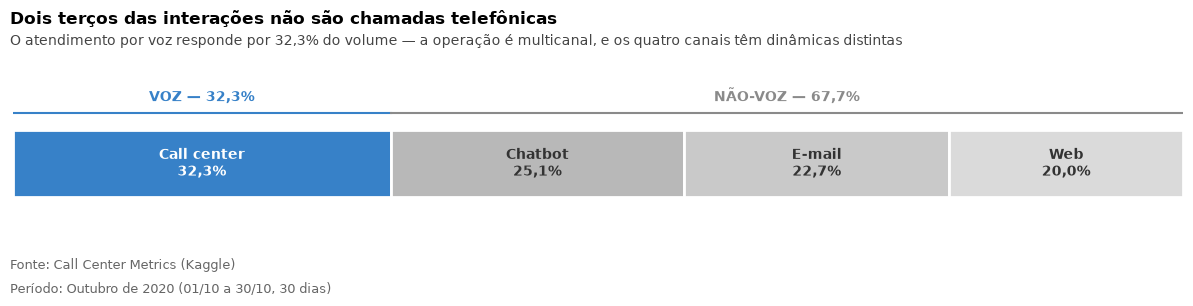

In [20]:
# =========================
# 1. Composição por canal
# =========================

CANAL_VOZ = "Call-Center"

mix_canal = df_analise["channel"].value_counts()
mix_pct = mix_canal / mix_canal.sum() * 100
share_voz = mix_pct[CANAL_VOZ]

# AHT por canal: a métrica é comparável entre canais tão diferentes?
aht_canal = (
    df_analise.groupby("channel", observed=True)["aht"]
    .agg(volume="size", media="mean", mediana="median", p90=lambda s: s.quantile(0.90))
)
aht_canal["share_%"] = (aht_canal["volume"] / aht_canal["volume"].sum() * 100).round(1)

print("COMPOSIÇÃO DA DEMANDA E TEMPO DE ATENDIMENTO POR CANAL")
print(tabela_br(aht_canal.round(2)))
print()
print(f"Voz ({CANAL_VOZ}): {pct_br(share_voz)} | Não-voz: {pct_br(100 - share_voz)}")
print(f"Amplitude do AHT médio entre canais: "
      f"{num_br(aht_canal['media'].max() - aht_canal['media'].min())} minuto "
      f"({(aht_canal['media'].max() - aht_canal['media'].min()) * 60:.0f} segundos)")

# =========================
# 2. Gráfico: barra única 100%
# =========================

fig, ax = plt.subplots(figsize=(12, 3.2))

cores_canal = {CANAL_VOZ: "#3781C8", "Chatbot": "#B8B8B8", "Email": "#C9C9C9", "Web": "#DADADA"}
ordem_canal = [CANAL_VOZ] + [c for c in mix_pct.index if c != CANAL_VOZ]

esquerda = 0
for canal in ordem_canal:
    largura = mix_pct[canal]
    ax.barh(0, largura, left=esquerda, height=0.45, color=cores_canal[canal],
            edgecolor="white", linewidth=2, zorder=3)
    ax.text(esquerda + largura / 2, 0, f"{rotulo(canal)}\n{pct_br(largura)}",
            ha="center", va="center", fontsize=10, fontweight="bold",
            color="white" if canal == CANAL_VOZ else "#333333", zorder=4)
    esquerda += largura

# colchetes voz / não-voz
for x0, x1, texto, cor in [
    (0, share_voz, f"VOZ — {pct_br(share_voz)}", "#3781C8"),
    (share_voz, 100, f"NÃO-VOZ — {pct_br(100 - share_voz)}", "#8A8A8A"),
]:
    ax.plot([x0, x1], [0.34, 0.34], color=cor, linewidth=1.5, zorder=3)
    ax.text((x0 + x1) / 2, 0.40, texto, ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=cor)

ax.set_xlim(0, 100)
ax.set_ylim(-0.35, 0.62)
ax.set_yticks([])
ax.set_xticks([])

# =========================
# 3. Padrão visual
# =========================

estilo_executivo(
    ax,
    titulo="Dois terços das interações não são chamadas telefônicas",
    subtitulo=(f"O atendimento por voz responde por {pct_br(share_voz)} do volume — "
               f"a operação é multicanal, e os quatro canais têm dinâmicas distintas"),
)

# gráfico de composição não tem eixos a exibir
for lado in ["left", "bottom"]:
    ax.spines[lado].set_visible(False)
ax.grid(False)

plt.show()

**Consequência para a terminologia.** O atendimento por voz representa apenas **32,3%** do volume; os outros 67,7% chegam por chatbot, e-mail e web. Tratar o conjunto como "chamadas" descreve incorretamente dois terços da operação: os rótulos dos gráficos passam a usar **contatos** ou **interações**.

O impacto na outra métrica-chave é mais sutil: a coluna de duração está preenchida para os quatro canais, mas os valores são idênticos entre eles:

| Canal | Volume | Share | AHT médio | Mediana | p90 |
|---|---|---|---|---|---|
| Call center | 10.638 | 32,3% | 25,05 | 25,0 | 41 |
| Chatbot | 8.256 | 25,1% | 24,92 | 25,0 | 41 |
| E-mail | 7.470 | 22,7% | 25,10 | 25,0 | 41 |
| Web | 6.576 | 20,0% | 25,02 | 25,0 | 42 |

A amplitude entre o maior e o menor AHT médio é de **0,18 minuto (11 segundos)**.

Isso não é plausível operacionalmente. Em uma operação real, o tempo de atendimento por voz, o tempo de tratativa de um e-mail e o tempo de uma sessão de chatbot diferem por múltiplos, não por segundos, e um chatbot sequer consome tempo de agente da mesma forma. Uma duração praticamente idêntica nos quatro canais indica que este campo é uma **duração genérica da base simulada**, não um AHT medido por canal.

Duas implicações para o restante da análise:

1. O gráfico de AHT por call center da Parte 1 (seção 2.4) e a distribuição da seção 3.7 agregam os quatro canais. Como a métrica não discrimina entre eles, ele deve ser lido como indicador de estabilidade da base, **não** como medida de eficiência operacional comparável entre canais.
2. Em uma base real, AHT é uma métrica de voz. As demais exigiriam indicadores próprios (concorrência de sessões para chat, tempo de resposta para e-mail) que não existem aqui.

A Parte 1 (seção 2.4) tratou indisponibilidade de serviço como um dos principais direcionadores de volume. Antes de aceitar essa leitura, é preciso situá-la: qual é o peso real de cada motivo de contato, e por onde cada um entra na operação.

VOLUME POR MOTIVO
                  volume share_% media_dia
reason                                    
Billing Question   23461    71,2     782,0
Payments            4749    14,4     158,0
Service Outage      4730    14,4     158,0

ROTEAMENTO — % de cada motivo por canal de entrada
channel          Call-Center Chatbot Email   Web
reason                                          
Billing Question        25,1    25,2  25,2  24,6
Payments               100,0     0,0   0,0   0,0
Service Outage           0,0    49,8  33,2  17,0


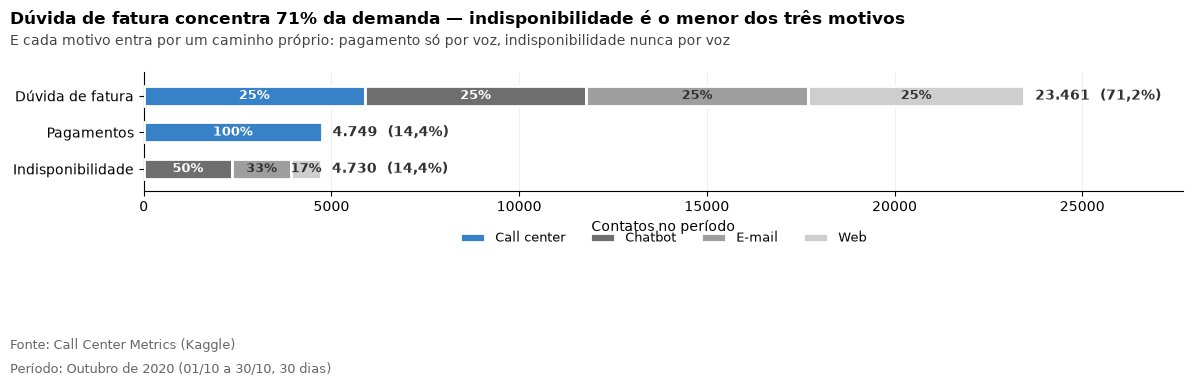

In [21]:
# =========================
# 1. Volume por motivo e roteamento por canal
# =========================

motivos = df_analise["reason"].value_counts()
motivos_pct = motivos / motivos.sum() * 100

# composição de canal DENTRO de cada motivo
motivo_canal = pd.crosstab(df_analise["reason"], df_analise["channel"])
motivo_canal_pct = motivo_canal.div(motivo_canal.sum(axis=1), axis=0) * 100

print("VOLUME POR MOTIVO")
print(tabela_br(pd.DataFrame({
    "volume": motivos,
    "share_%": motivos_pct.round(1),
    "media_dia": (motivos / df_analise["date"].nunique()).round(0),
})))

print()
print("ROTEAMENTO — % de cada motivo por canal de entrada")
print(tabela_br(motivo_canal_pct.round(1)))

# =========================
# 2. Gráfico: volume por motivo, segmentado por canal
# =========================

CANAIS_ORDEM = ["Call-Center", "Chatbot", "Email", "Web"]
CORES_CANAL = {"Call-Center": "#3781C8", "Chatbot": "#6E6E6E", "Email": "#9E9E9E", "Web": "#CECECE"}

ordem_motivos = motivos.index[::-1]   # maior volume no topo

fig, ax = plt.subplots(figsize=(12, 4.0))

for i, motivo in enumerate(ordem_motivos):
    esquerda = 0
    for canal in CANAIS_ORDEM:
        largura = motivo_canal.loc[motivo, canal]
        if largura == 0:
            continue
        ax.barh(i, largura, left=esquerda, height=0.55,
                color=CORES_CANAL[canal], edgecolor="white", linewidth=2,
                zorder=3, label=rotulo(canal) if i == len(ordem_motivos) - 1 else None)
        pct_interno = motivo_canal_pct.loc[motivo, canal]
        if pct_interno >= 15:        # só rotula segmentos que comportam o texto
            ax.text(esquerda + largura / 2, i, pct_br(pct_interno, 0),
                    ha="center", va="center", fontsize=9, fontweight="bold",
                    color="white" if canal in ("Call-Center", "Chatbot") else "#333333",
                    zorder=4)
        esquerda += largura

    # total à direita da barra
    ax.text(esquerda + motivos.max() * 0.012, i,
            f"{motivos[motivo]:,}".replace(",", ".") + f"  ({pct_br(motivos_pct[motivo])})",
            va="center", fontsize=10, fontweight="bold", color="#333333")

ax.set_yticks(range(len(ordem_motivos)))
ax.set_yticklabels([rotulo(m) for m in ordem_motivos], fontsize=10)
ax.set_xlim(0, motivos.max() * 1.18)
ax.set_ylim(-0.6, len(ordem_motivos) - 0.35)

# legenda de canais (identidade não pode depender só da cor)
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles, labels_leg, loc="upper center", bbox_to_anchor=(0.5, -0.24),
          ncol=4, frameon=False, fontsize=9)

# =========================
# 3. Padrão visual
# =========================

estilo_executivo(
    ax,
    titulo="Dúvida de fatura concentra 71% da demanda — indisponibilidade é o menor dos três motivos",
    subtitulo="E cada motivo entra por um caminho próprio: pagamento só por voz, indisponibilidade nunca por voz",
    xlabel="Contatos no período",
    grid_axis="x"
)

plt.show()

**O motivo dominante não estava na análise.** Dúvidas de fatura somam 23.461 contatos (71,2% do volume, ~782 por dia). Pagamentos e indisponibilidade empatam em 14,4% cada (~158 por dia). A indisponibilidade de serviço, tratada até aqui como direcionador principal de volume, é na verdade **o menor dos três motivos**.

**O roteamento também é rígido em dois dos três motivos**, e isso nenhuma análise anterior havia notado: dúvidas de fatura se dividem por igual entre os canais, mas pagamento e indisponibilidade têm caminho fixo:

| Motivo | Call center | Chatbot | E-mail | Web |
|---|---|---|---|---|
| Dúvida de fatura | 25,1% | 25,2% | 25,2% | 24,6% |
| Pagamentos | **100,0%** | 0,0% | 0,0% | 0,0% |
| Indisponibilidade | **0,0%** | 49,8% | 33,2% | 17,0% |

O canal de voz atende exclusivamente dúvidas de fatura (5.889) e pagamentos (4.749): soma exata dos 10.638 contatos de voz. Indisponibilidade **nunca** entra por telefone; chega apenas por canais digitais.

Isso tem duas consequências operacionais diretas:

1. **Um pico de indisponibilidade não pressiona a fila de voz.** Ele pressiona chatbot, e-mail e web. Qualquer plano de contingência para incidentes precisa dimensionar a capacidade digital, não a telefônica.
2. **Pagamento é um ponto único de falha.** Sendo 100% voz, uma indisponibilidade do canal telefônico interrompe integralmente a captura desse tipo de contato: não há caminho alternativo na operação atual.

**Onde está a alavanca de volume.** A demanda está concentrada em um único motivo altamente padronizável. A aritmética: cada **10% de desvio das dúvidas de fatura** para autoatendimento remove **2.346 contatos** do período, equivalente a **7,1% do volume total**.

Esse é o efeito sobre o **volume**, não sobre o SLA. Se menos volume se traduz em mais aderência depende de a operação estar limitada por capacidade, e é isso que as seções 3.5 e 5.3 discutem.


## 3.5 A concentração de volume explica o gap?

Se a sobrecarga dos centros de alto volume fosse a causa da perda de SLA, esperaríamos aderência **menor** em Los Angeles e Baltimore e **maior** em Denver, o centro ocioso.

O gráfico abaixo mede a aderência de cada centro com intervalo de confiança de 95%, acompanhado de um teste qui-quadrado de independência. O intervalo de confiança é indispensável aqui: com bases de tamanhos muito diferentes (13.734 contatos em Los Angeles contra 2.776 em Denver), uma diferença de décimos de ponto pode ser apenas ruído amostral.

**Nota sobre o teste.** O qui-quadrado (χ²) mede o quanto a distribuição observada nas categorias (aqui, aderência ao SLA por call center) se afasta do que seria esperado se as duas variáveis fossem independentes: quanto maior o χ², maior o afastamento. O **valor crítico a 5%** é o limiar acima do qual esse afastamento é grande demais para ser atribuído ao acaso (a convenção de tolerar, no máximo, 5% de chance de enxergar associação onde não há); ele depende do número de graus de liberdade (categorias − 1) e vem de tabela, não é calculado a partir dos dados. A leitura é direta: χ² acima do crítico → há associação estatística entre as variáveis; χ² abaixo → não há evidência de associação. Essa mesma leitura se repete em cada teste da Parte 2.

                volume share_%  sla_% ic95_pp
call_center                                  
Los Angeles/CA   13734    41,7  75,78    0,72
Baltimore/MD     11012    33,4  74,86    0,81
Chicago/IL        5418    16,4  74,88    1,15
Denver/CO         2776     8,4  75,07    1,61

Qui-quadrado: χ² = 3,36 (gl = 3) | crítico a 5% = 7,81 -> SEM diferença significativa
Maior diferença: Los Angeles/CA - Baltimore/MD = +0,91pp | IC 95% [-0,17; +1,99]pp -> contém zero
Amplitude entre o melhor e o pior centro: 0,91pp | Distância da média até a meta: 4,74pp


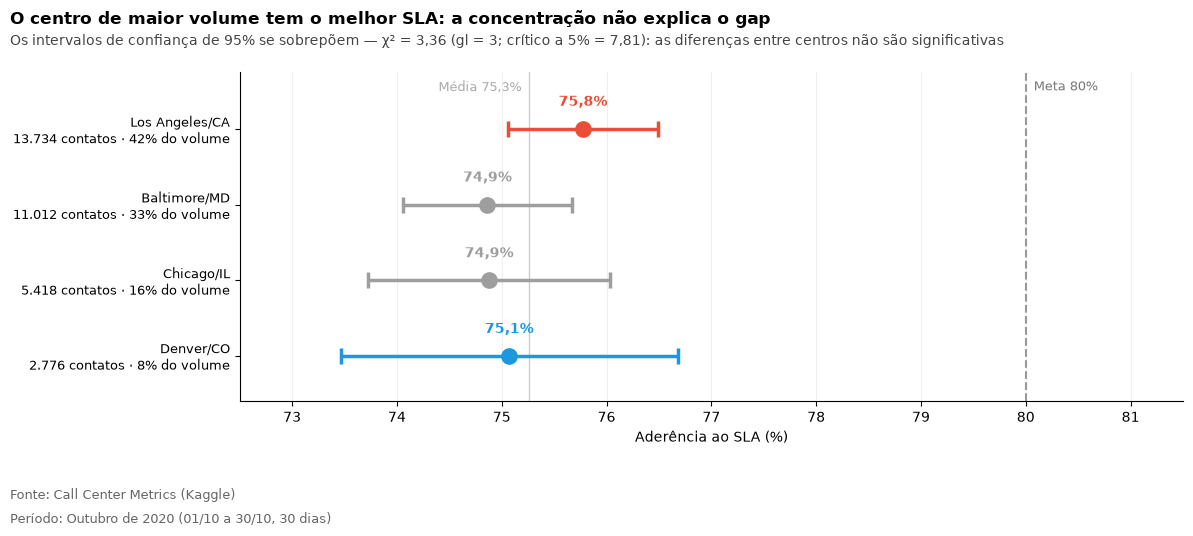

In [22]:
# =========================
# 1. Aderência por call center com IC 95%
# =========================

sla_centro = (
    df_analise.groupby("call_center", observed=True)
              .agg(volume=("sla_ok", "size"), sla=("sla_ok", "mean"))
              .sort_values("volume", ascending=False)
)

sla_centro["share"] = sla_centro["volume"] / sla_centro["volume"].sum()

# IC 95% da proporção: 1,96 * erro padrão
sla_centro["ic95"] = 1.96 * np.sqrt(
    sla_centro["sla"] * (1 - sla_centro["sla"]) / sla_centro["volume"]
)

# =========================
# 2. Teste qui-quadrado de independência (SLA x call center)
# =========================

observado = pd.crosstab(df_analise["call_center"], df_analise["sla_ok"]).values.astype(float)
esperado = observado.sum(1, keepdims=True) @ observado.sum(0, keepdims=True) / observado.sum()

chi2 = ((observado - esperado) ** 2 / esperado).sum()
gl = (observado.shape[0] - 1) * (observado.shape[1] - 1)
CRITICO_5PCT = {1: 3.84, 2: 5.99, 3: 7.81, 4: 9.49}[gl]

# =========================
# 3. Maior diferença par a par (com IC da diferença)
# =========================

melhor, pior = sla_centro["sla"].idxmax(), sla_centro["sla"].idxmin()
p1, n1 = sla_centro.loc[melhor, "sla"], sla_centro.loc[melhor, "volume"]
p2, n2 = sla_centro.loc[pior, "sla"], sla_centro.loc[pior, "volume"]

dif = p1 - p2
ic_dif = 1.96 * np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)

print(tabela_br(sla_centro.assign(
    **{"share_%": (sla_centro["share"] * 100).round(1),
       "sla_%": (sla_centro["sla"] * 100).round(2),
       "ic95_pp": (sla_centro["ic95"] * 100).round(2)}
)[["volume", "share_%", "sla_%", "ic95_pp"]]))

print()
print(f"Qui-quadrado: χ² = {num_br(chi2)} (gl = {gl}) | crítico a 5% = {num_br(CRITICO_5PCT)} "
      f"-> {'diferença significativa' if chi2 > CRITICO_5PCT else 'SEM diferença significativa'}")
print(f"Maior diferença: {melhor} - {pior} = {num_br(dif * 100, sinal=True)}pp "
      f"| IC 95% [{num_br((dif - ic_dif) * 100, sinal=True)}; {num_br((dif + ic_dif) * 100, sinal=True)}]pp "
      f"-> {'não contém zero' if (dif - ic_dif) * (dif + ic_dif) > 0 else 'contém zero'}")
print(f"Amplitude entre o melhor e o pior centro: {pp(dif * 100)} | "
      f"Distância da média até a meta: {pp((META_SLA - df_analise['sla_ok'].mean()) * 100)}")

# =========================
# 4. Gráfico
# =========================

plt.figure(figsize=(12, 5.5))
ax = plt.gca()

# a história é "não há diferença": um cinza para todos, destaque apenas nos dois
# centros que a narrativa original contrapunha (mesmas cores dos demais gráficos)
highlight_centers = {
    "Los Angeles/CA": "#E94F37",
    "Denver/CO": "#1B98E0"
}

ordem = sla_centro.index[::-1]   # maior volume no topo
sla_global = df_analise["sla_ok"].mean()

# linhas de referência
ax.axvline(META_SLA * 100, linestyle="--", color="#999999", linewidth=1.5, zorder=1)
ax.axvline(sla_global * 100, color="#CCCCCC", linewidth=1, zorder=1)

for i, centro in enumerate(ordem):
    cor = highlight_centers.get(centro, "#9E9E9E")
    linha = sla_centro.loc[centro]
    ax.errorbar(
        linha["sla"] * 100, i, xerr=linha["ic95"] * 100,
        fmt="o", markersize=11, color=cor, ecolor=cor,
        elinewidth=2.5, capsize=6, capthick=2.5, zorder=3
    )
    ax.text(
        linha["sla"] * 100, i + 0.26, pct_br(linha["sla"] * 100),
        color=cor, ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_yticks(range(len(ordem)))
ax.set_yticklabels([
    f"{c}\n{sla_centro.loc[c, 'volume']:,} contatos · {sla_centro.loc[c, 'share']:.0%} do volume".replace(",", ".")
    for c in ordem
], fontsize=9)
ax.set_ylim(-0.6, len(ordem) - 0.25)
ax.set_xlim(72.5, 81.5)

ax.text(META_SLA * 100, len(ordem) - 0.45, "  Meta 80%",
        color="#777777", fontsize=9, va="center")
ax.text(sla_global * 100, len(ordem) - 0.45, f"Média {pct_br(sla_global * 100)}  ",
        color="#AAAAAA", fontsize=9, va="center", ha="right")

# =========================
# 5. Padrão visual
# =========================

estilo_executivo(
    ax,
    titulo="O centro de maior volume tem o melhor SLA: a concentração não explica o gap",
    subtitulo=(f"Os intervalos de confiança de 95% se sobrepõem — χ² = {num_br(chi2)} "
               f"(gl = {gl}; crítico a 5% = {num_br(CRITICO_5PCT)}): as diferenças entre centros não são significativas"),
    xlabel="Aderência ao SLA (%)",
    grid_axis="x"
)

plt.show()

**A hipótese não se sustenta.** Los Angeles, que concentra 42% do volume, registra a **maior** aderência (75,8%); Denver, com 8% do volume (o centro que a Parte 1 supunha ocioso), fica em 75,1%, abaixo de Los Angeles.

Os quatro intervalos de confiança se sobrepõem, e os testes confirmam o que o gráfico mostra:

- **Qui-quadrado:** χ² = 3,36 com 3 graus de liberdade, contra um valor crítico de 7,81 a 5%. Não há associação estatisticamente significativa entre call center e aderência ao SLA.
- **Maior diferença par a par:** Los Angeles − Baltimore = +0,91pp, com IC 95% de [−0,17; +1,99]pp. O intervalo **contém zero**, ou seja, nem a maior diferença observada entre dois centros é distinguível de acaso.

A comparação de magnitudes fecha o argumento: a amplitude entre o melhor e o pior centro é de **0,91pp**, enquanto a distância da média até a meta é de **4,74pp**. Mesmo que toda a diferença entre centros fosse real e pudesse ser eliminada por rebalanceamento, isso cobriria menos de um quinto do gap.

Na prática, não há evidência de que redistribuir contatos de Los Angeles para Denver melhoraria o SLA: a ação mais intuitiva a partir do gráfico anterior é, pelos dados, ineficaz. O direcionador do gap está em outro lugar, e as seções seguintes testam os candidatos restantes.

A concentração de volume entre call centers não explica o gap. Mas antes de tirar conclusões precipitadas, precisamos testar **as outras dimensões que a base permite**. Caso contrário, a conclusão seria apenas "não achei a causa onde procurei", o que é bem diferente de "a causa não está aqui"!

As dimensões candidatas são: **canal** de atendimento, **motivo** do contato e **dia da semana**. O painel abaixo repete o mesmo rigor do teste anterior para podermos comparar lado a lado.


TESTE DE INDEPENDÊNCIA — SLA vs. cada dimensão disponível
     dimensão  categorias amplitude_pp qui_quadrado  gl crítico_5% significativo
  Call center           4         0,91         3,36   3       7,81           não
        Canal           4         0,76         2,10   3       7,81           não
       Motivo           3         1,16         2,86   2       5,99           não
Dia da semana           7         1,48         5,46   6      12,59           não

Correlação entre volume diário e aderência diária: r = -0,215 (n = 30 dias; |r| crítico a 5% = 0,361) -> NÃO significativa


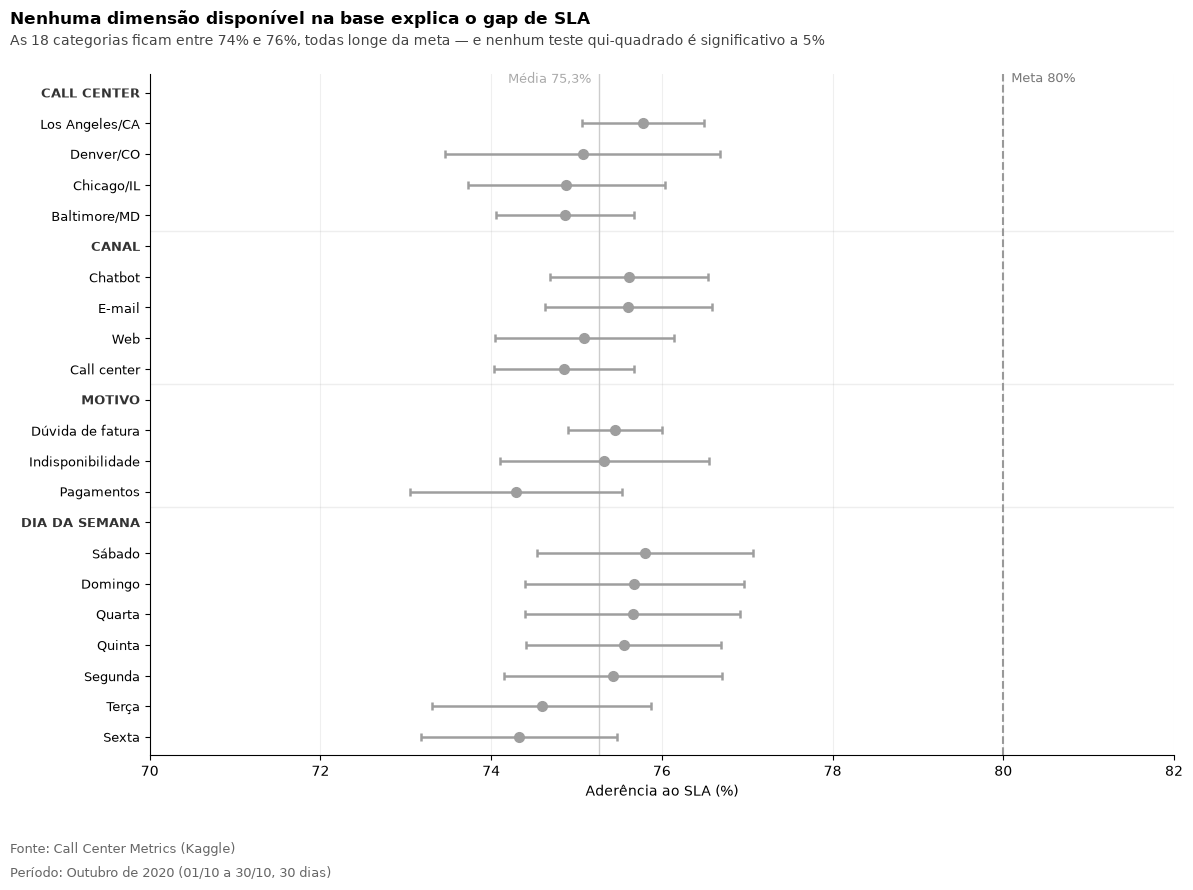

In [23]:
# =========================
# 1. Dimensão temporal adicional
# =========================

df_analise["dia_semana"] = df_analise["date"].dt.day_name().map(rotulo)

# =========================
# 2. Função de teste (mesmo procedimento aplicado a cada dimensão)
# =========================

CRITICO_5PCT = {1: 3.84, 2: 5.99, 3: 7.81, 4: 9.49, 5: 11.07, 6: 12.59}


def testar_dimensao(coluna):
    """Aderência por categoria com IC 95% + qui-quadrado de independência."""
    g = (
        df_analise.groupby(coluna, observed=True)["sla_ok"]
        .agg(volume="size", sla="mean")
        .sort_values("sla", ascending=False)
    )
    g["ic95"] = 1.96 * np.sqrt(g["sla"] * (1 - g["sla"]) / g["volume"])

    obs = pd.crosstab(df_analise[coluna], df_analise["sla_ok"]).values.astype(float)
    esp = obs.sum(1, keepdims=True) @ obs.sum(0, keepdims=True) / obs.sum()
    chi2 = ((obs - esp) ** 2 / esp).sum()
    gl = (obs.shape[0] - 1) * (obs.shape[1] - 1)

    return g, chi2, gl, CRITICO_5PCT[gl]


DIMENSOES = {
    "Call center": "call_center",
    "Canal": "channel",
    "Motivo": "reason",
    "Dia da semana": "dia_semana",
}

resultados, resumo = {}, []

for nome, coluna in DIMENSOES.items():
    g, chi2, gl, critico = testar_dimensao(coluna)
    resultados[nome] = g
    resumo.append({
        "dimensão": nome,
        "categorias": len(g),
        "amplitude_pp": round((g["sla"].max() - g["sla"].min()) * 100, 2),
        "qui_quadrado": round(chi2, 2),
        "gl": gl,
        "crítico_5%": critico,
        "significativo": "SIM" if chi2 > critico else "não",
    })

resumo = pd.DataFrame(resumo)
print("TESTE DE INDEPENDÊNCIA — SLA vs. cada dimensão disponível")
print(tabela_br(resumo, index=False))

# =========================
# 3. Teste adicional: dias de maior volume têm SLA pior?
# =========================

diario = df_analise.groupby("date").agg(volume=("sla_ok", "size"), sla=("sla_ok", "mean"))
r = diario["volume"].corr(diario["sla"])
R_CRITICO_30D = 0.361   # |r| mínimo para significância a 5% com n = 30

print()
print(f"Correlação entre volume diário e aderência diária: r = {num_br(r, 3, sinal=True)} "
      f"(n = {len(diario)} dias; |r| crítico a 5% = {num_br(R_CRITICO_30D, 3)}) "
      f"-> {'significativa' if abs(r) > R_CRITICO_30D else 'NÃO significativa'}")

# =========================
# 4. Painel comparativo (forest plot)
# =========================

sla_global = df_analise["sla_ok"].mean()
n_linhas = sum(len(g) for g in resultados.values()) + len(resultados)

fig, ax = plt.subplots(figsize=(12, 0.32 * n_linhas + 2.0))

y, ticks, labels, separadores = 0, [], [], []

for nome, g in resultados.items():
    ticks.append(y)
    labels.append(nome.upper())
    y += 1
    for categoria, linha in g.iterrows():
        ax.errorbar(
            linha["sla"] * 100, y, xerr=linha["ic95"] * 100,
            fmt="o", markersize=7, color="#9E9E9E", ecolor="#9E9E9E",
            elinewidth=1.8, capsize=3, capthick=1.8, zorder=3
        )
        ticks.append(y)
        labels.append(f"    {rotulo(categoria)}")
        y += 1
    separadores.append(y - 0.5)

# linhas de referência
ax.axvline(META_SLA * 100, linestyle="--", color="#999999", linewidth=1.5, zorder=1)
ax.axvline(sla_global * 100, color="#CCCCCC", linewidth=1, zorder=1)

for s in separadores[:-1]:
    ax.axhline(s, color="#EEEEEE", linewidth=1, zorder=0)

ax.set_yticks(ticks)
ax.set_yticklabels(labels, fontsize=9)
for tick, texto in zip(ax.get_yticklabels(), labels):
    if not texto.startswith(" "):        # cabeçalho de grupo
        tick.set_fontweight("bold")
        tick.set_color("#333333")

ax.set_ylim(y - 0.4, -0.6)
ax.set_xlim(70, 82)

ax.text(META_SLA * 100, -0.45, "  Meta 80%", color="#777777", fontsize=9, va="center")
ax.text(sla_global * 100, -0.45, f"Média {pct_br(sla_global * 100)}  ",
        color="#AAAAAA", fontsize=9, va="center", ha="right")

# =========================
# 5. Padrão visual
# =========================

estilo_executivo(
    ax,
    titulo="Nenhuma dimensão disponível na base explica o gap de SLA",
    subtitulo=(f"As {n_linhas - len(resultados)} categorias ficam entre 74% e 76%, "
               f"todas longe da meta — e nenhum teste qui-quadrado é significativo a 5%"),
    xlabel="Aderência ao SLA (%)",
    grid_axis="x"
)

plt.show()

**O gap é uniforme em todas as dimensões mensuráveis.** Nenhum dos quatro testes é significativo a 5%, e as amplitudes internas são desprezíveis frente aos 4,74pp que separam a operação da meta:

| Dimensão | Categorias | Amplitude interna | χ² | Crítico 5% | Significativo |
|---|---|---|---|---|---|
| Call center | 4 | 0,91pp | 3,36 | 7,81 | não |
| Canal | 4 | 0,76pp | 2,10 | 7,81 | não |
| Motivo | 3 | 1,16pp | 2,86 | 5,99 | não |
| Dia da semana | 7 | 1,48pp | 5,46 | 12,59 | não |

A hipótese de carga também foi testada no eixo temporal: a correlação entre volume diário e aderência diária é de **r = −0,215** (n = 30 dias), abaixo do |r| crítico de 0,361 a 5%. Dias mais movimentados **não** têm SLA pior.

**Como ler esse resultado.** Um gap que aparece igual em todo lugar não tem causa local: ele não está em um centro, um canal, um tipo de demanda ou um dia da semana. Um déficit uniforme de ~4,7pp aponta para uma restrição **agregada**, que atinge a operação inteira da mesma forma: dimensionamento de pessoal frente ao volume total, ou um limite estrutural de processo.

E essa é precisamente a variável que **não existe nesta base**. Não há coluna de agente, headcount, escala ou tempo logado, nem granularidade de hora, já que todos os timestamps são 00:00:00. O que a análise pode afirmar com honestidade é onde a causa **não** está, o que já elimina as ações mais intuitivas (e mais caras) da lista, e indicar exatamente qual dado é preciso obter para fechar o diagnóstico.

O teste anterior cobriu a **aderência** por dia da semana. Falta a outra metade da pergunta, que é a que determina dimensionamento: o **volume** varia conforme o dia da semana?

Essa comparação exige um cuidado específico. A janela de análise tem 30 dias, e outubro de 2020 começa numa quinta-feira, portanto há **cinco** quintas e cinco sextas, mas apenas **quatro** de cada outro dia. Comparar totais acumulados mediria a quantidade de ocorrências de cada dia no calendário, não a intensidade da demanda.

VOLUME POR DIA DA SEMANA
            ocorrencias  total   media desvio  ic95
dia_semana                                         
Segunda               4   4334  1083,5   20,6  32,8
Terça                 4   4408  1102,0   40,6  64,6
Quarta                4   4449  1112,2   55,9  88,9
Quinta                5   5481  1096,2   44,3  55,0
Sexta                 5   5570  1114,0   18,4  22,8
Sábado                4   4402  1100,5   15,5  24,6
Domingo               4   4296  1074,0   21,9  34,9

Amplitude pelo TOTAL acumulado : 1,297x (1274 contatos de diferença)
Amplitude pela MÉDIA diária    : 1,037x (40 contatos/dia de diferença)

Sobreposição dos intervalos de confiança: SIM — nenhum dia se destaca


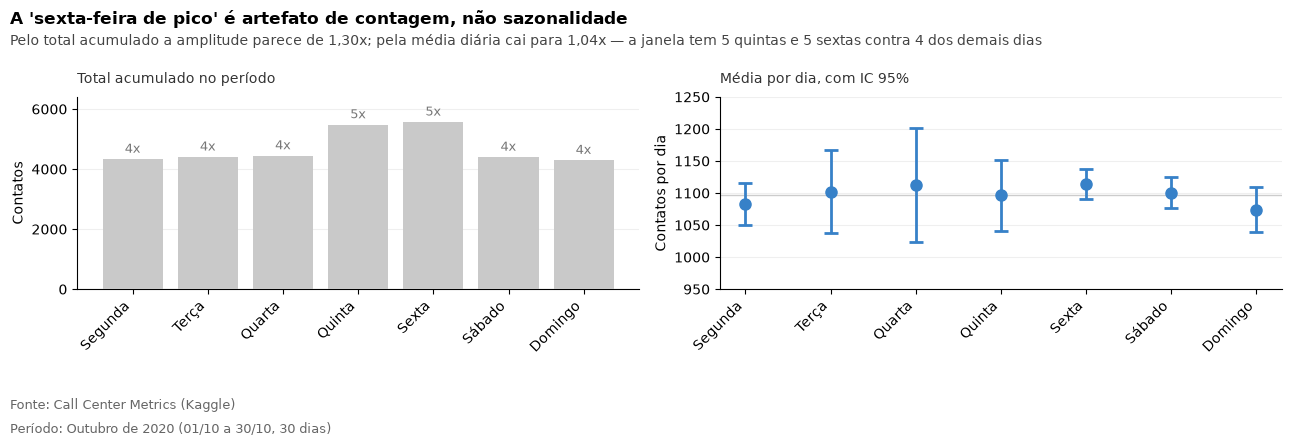

In [24]:
# =========================
# 1. Volume por dia da semana: total vs. média diária
# =========================

ORDEM_SEMANA = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]

volume_diario = df_analise.groupby(["dia_semana", "date"]).size().reset_index(name="contatos")

semana = volume_diario.groupby("dia_semana")["contatos"].agg(
    ocorrencias="size", total="sum", media="mean", desvio="std"
).reindex(ORDEM_SEMANA)

# Com 4 ou 5 observações por dia da semana, o multiplicador correto é o t de
# Student (não 1,96): com n tão pequeno, usar z subestimaria muito o intervalo.
T_CRITICO_95 = {1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571, 6: 2.447}
semana["ic95"] = semana.apply(
    lambda r: T_CRITICO_95[int(r["ocorrencias"]) - 1] * r["desvio"] / np.sqrt(r["ocorrencias"]),
    axis=1
)

amp_total = semana["total"].max() / semana["total"].min()
amp_media = semana["media"].max() / semana["media"].min()

print("VOLUME POR DIA DA SEMANA")
print(tabela_br(semana.round(1)))
print()
print(f"Amplitude pelo TOTAL acumulado : {num_br(amp_total, 3)}x "
      f"({semana['total'].max() - semana['total'].min():.0f} contatos de diferença)")
print(f"Amplitude pela MÉDIA diária    : {num_br(amp_media, 3)}x "
      f"({semana['media'].max() - semana['media'].min():.0f} contatos/dia de diferença)")
print()
print("Sobreposição dos intervalos de confiança: "
      f"{'SIM — nenhum dia se destaca' if semana['media'].min() + semana.loc[semana['media'].idxmin(), 'ic95'] > semana['media'].max() - semana.loc[semana['media'].idxmax(), 'ic95'] else 'NÃO'}")

# =========================
# 2. Gráfico: o que o total sugere vs. o que a média mostra
# =========================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- painel esquerdo: total acumulado (a leitura enganosa) ---
ax1.bar(semana.index, semana["total"], color="#C9C9C9", zorder=3)
for i, (dia, linha) in enumerate(semana.iterrows()):
    ax1.text(i, linha["total"] + semana["total"].max() * 0.02,
             f"{int(linha['ocorrencias'])}x", ha="center", va="bottom",
             fontsize=9, color="#777777")
ax1.set_title("Total acumulado no período", fontsize=10, loc="left", color="#333333", pad=10)
ax1.set_ylabel("Contatos")
ax1.set_ylim(0, semana["total"].max() * 1.15)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# --- painel direito: média diária com IC 95% (a leitura correta) ---
ax2.errorbar(
    range(len(semana)), semana["media"], yerr=semana["ic95"],
    fmt="o", markersize=8, color="#3781C8", ecolor="#3781C8",
    elinewidth=2, capsize=5, capthick=2, zorder=3, linestyle="none"
)
ax2.axhline(semana["media"].mean(), color="#CCCCCC", linewidth=1, zorder=1)
ax2.set_xticks(range(len(semana)))
ax2.set_xticklabels(semana.index)
ax2.set_title("Média por dia, com IC 95%", fontsize=10, loc="left", color="#333333", pad=10)
ax2.set_ylabel("Contatos por dia")
ax2.set_ylim(950, 1250)
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

# =========================
# 3. Padrão visual
# =========================

estilo_executivo(
    ax1,
    titulo="A 'sexta-feira de pico' é artefato de contagem, não sazonalidade",
    subtitulo=(f"Pelo total acumulado a amplitude parece de {amp_total:.2f}x; "
               f"pela média diária cai para {amp_media:.2f}x — a janela tem 5 quintas e 5 sextas "
               f"contra 4 dos demais dias").replace(".", ","),
    ylabel="Contatos",
    eixos_extra=(ax2,)
)

plt.show()

**Não há sazonalidade semanal mensurável.** Corrigida a contagem, a média diária fica entre 1.074 e 1.114 contatos: amplitude de **1,04x**, contra os 1,30x que o total acumulado sugeria. Os intervalos de confiança de 95% se sobrepõem entre todos os dias.

Duas observações metodológicas que este teste torna concretas:

1. **Total acumulado por categoria de calendário só é comparável se as categorias ocorrerem o mesmo número de vezes.** Aqui, cinco quintas e cinco sextas contra quatro dos demais produziam uma diferença aparente de 1.274 contatos que é puramente aritmética. Uma recomendação de reforçar a escala às sextas-feiras teria saído de um artefato.
2. **Com 4 ou 5 observações por grupo, o multiplicador do intervalo é o t de Student, não 1,96.** Para n = 4 o valor correto é 3,182, 62% mais largo que o z. Usar 1,96 aqui produziria intervalos artificialmente estreitos e faria dois dias parecerem diferentes quando não são.

**Implicação para WFM.** Uma operação real costuma apresentar sazonalidade semanal marcada: fins de semana com uma fração do volume dos dias úteis. A ausência total de padrão aqui, somada ao coeficiente de variação diário de apenas 3%, confirma que a base é simulada com volume essencialmente uniforme. Na prática isso significa que **não há base para diferenciar o dimensionamento por dia da semana**: a escala deve ser plana, e qualquer variação de capacidade precisaria ser justificada por dados que esta base não contém.

## 3.6 O SLA se traduz em experiência do cliente?

A Parte 1 trata operação e experiência como faces do mesmo problema. É a suposição mais intuitiva do projeto, e a que menos foi questionada, justamente por parecer óbvia. Será que ela se sustenta?

Se essa ponte realmente existir, os contatos atendidos **abaixo** do SLA deveriam apresentar um CSAT mais baixo que os atendidos dentro dele. O teste abaixo compara a nota média por status de SLA. Vamos dar uma olhada!


CSAT MÉDIO POR STATUS DE SLA (escala 1 a 10)
            respondentes  media desvio   ic95
SLA                                          
Above SLA           1518  5,619  2,399  0,121
Below SLA           3095  5,563  2,375  0,084
Within SLA          7658  5,529  2,364  0,053

Maior diferença: Acima do SLA - Dentro do SLA = +0,090 ponto | IC 95% [-0,042; +0,222] -> contém zero
Em proporção da escala (1 a 10): 1,0%

Correlação entre aderência diária e CSAT diário: r = +0,230 (n = 30 dias; |r| crítico a 5% = 0,361) -> NÃO significativa
Sentimento vs. aderência: χ² = 0,43 (gl = 4; crítico a 5% = 9,49) -> SEM associação


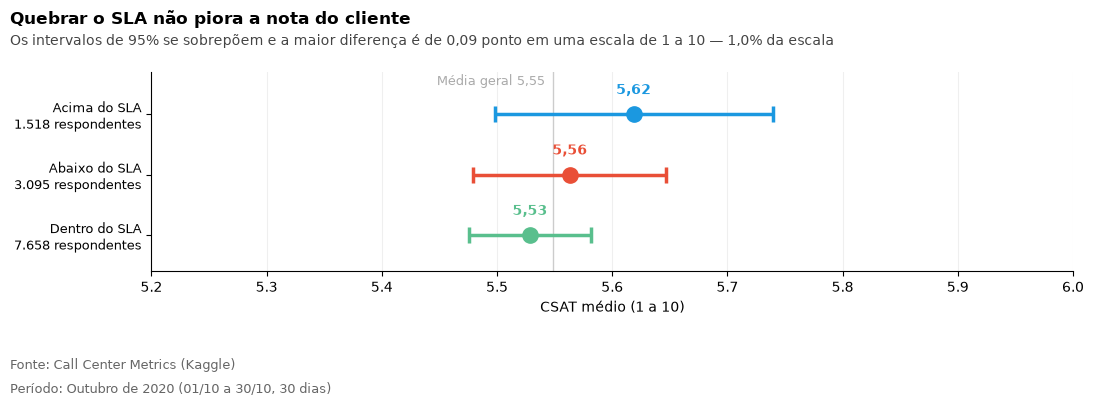

In [25]:
# =========================
# 1. CSAT por status de SLA, com IC 95%
# =========================

csat_por_sla = (
    df_analise.groupby("SLA", observed=True)["csat_score"]
    .agg(respondentes="count", media="mean", desvio="std")
)
csat_por_sla["ic95"] = 1.96 * csat_por_sla["desvio"] / np.sqrt(csat_por_sla["respondentes"])
csat_por_sla = csat_por_sla.sort_values("media", ascending=False)

print("CSAT MÉDIO POR STATUS DE SLA (escala 1 a 10)")
print(tabela_br(csat_por_sla.round(3)))

# diferença entre o melhor e o pior status, com IC da diferença
melhor, pior = csat_por_sla.index[0], csat_por_sla.index[-1]
m1, s1, n1 = csat_por_sla.loc[melhor, ["media", "desvio", "respondentes"]]
m2, s2, n2 = csat_por_sla.loc[pior, ["media", "desvio", "respondentes"]]

dif = m1 - m2
ic_dif = 1.96 * np.sqrt(s1**2 / n1 + s2**2 / n2)

print()
print(f"Maior diferença: {rotulo(melhor)} - {rotulo(pior)} = {num_br(dif, 3, sinal=True)} ponto "
      f"| IC 95% [{num_br(dif - ic_dif, 3, sinal=True)}; {num_br(dif + ic_dif, 3, sinal=True)}] "
      f"-> {'não contém zero' if (dif - ic_dif) * (dif + ic_dif) > 0 else 'contém zero'}")
print(f"Em proporção da escala (1 a 10): {pct_br(dif / 9 * 100)}")

# =========================
# 2. Testes complementares
# =========================

# 2a. no eixo do tempo: dias de SLA melhor têm CSAT melhor?
diario = df_analise.groupby("date").agg(sla=("sla_ok", "mean"), csat=("csat_score", "mean"))
r_csat = diario["sla"].corr(diario["csat"])

print()
print(f"Correlação entre aderência diária e CSAT diário: r = {num_br(r_csat, 3, sinal=True)} "
      f"(n = {len(diario)} dias; |r| crítico a 5% = {num_br(R_CRITICO_30D, 3)}) "
      f"-> {'significativa' if abs(r_csat) > R_CRITICO_30D else 'NÃO significativa'}")

# 2b. o sentimento se distribui de forma diferente conforme o SLA?
_, chi2_sent, gl_sent, critico_sent = testar_dimensao("sentiment")

print(f"Sentimento vs. aderência: χ² = {num_br(chi2_sent)} (gl = {gl_sent}; "
      f"crítico a 5% = {num_br(critico_sent)}) "
      f"-> {'associação significativa' if chi2_sent > critico_sent else 'SEM associação'}")

# =========================
# 3. Gráfico
# =========================

plt.figure(figsize=(11, 4.2))
ax = plt.gca()

# mesmas cores que identificam os status no gráfico da seção 2.2 (Parte 1)
cores_sla = {
    "Below SLA": "#E94F37",
    "Within SLA": "#59BF8D",
    "Above SLA": "#1B98E0"
}

csat_global = df_analise["csat_score"].mean()
ax.axvline(csat_global, color="#CCCCCC", linewidth=1, zorder=1)

ordem = csat_por_sla.index[::-1]

for i, status in enumerate(ordem):
    linha = csat_por_sla.loc[status]
    cor = cores_sla[status]
    ax.errorbar(
        linha["media"], i, xerr=linha["ic95"],
        fmt="o", markersize=11, color=cor, ecolor=cor,
        elinewidth=2.5, capsize=6, capthick=2.5, zorder=3
    )
    ax.text(linha["media"], i + 0.28, f"{linha['media']:.2f}".replace(".", ","),
            color=cor, ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_yticks(range(len(ordem)))
ax.set_yticklabels([
    f"{rotulo(s)}\n{int(csat_por_sla.loc[s, 'respondentes']):,} respondentes".replace(",", ".")
    for s in ordem
], fontsize=9)
ax.set_ylim(-0.6, len(ordem) - 0.3)
ax.set_xlim(5.2, 6.0)

ax.text(csat_global, len(ordem) - 0.45,
        f"Média geral {csat_global:.2f}  ".replace(".", ","),
        color="#AAAAAA", fontsize=9, va="center", ha="right")

# =========================
# 4. Padrão visual
# =========================

dif_txt = f"{dif:.2f}".replace(".", ",")
escala_txt = f"{dif / 9 * 100:.1f}".replace(".", ",")

estilo_executivo(
    ax,
    titulo="Quebrar o SLA não piora a nota do cliente",
    subtitulo=(f"Os intervalos de 95% se sobrepõem e a maior diferença é de {dif_txt} ponto "
               f"em uma escala de 1 a 10 — {escala_txt}% da escala"),
    xlabel="CSAT médio (1 a 10)",
    grid_axis="x"
)

plt.show()

**A ponte não existe nos dados.** As três médias ficam entre 5,53 e 5,62 em uma escala de 1 a 10, com intervalos de confiança sobrepostos:

| Status de SLA | Respondentes | CSAT médio | IC 95% |
|---|---|---|---|
| Acima do SLA | 1.518 | 5,62 | ±0,12 |
| Abaixo do SLA | 3.095 | 5,56 | ±0,08 |
| Dentro do SLA | 7.658 | 5,53 | ±0,05 |

Três observações fecham o caso:

1. **Não há sequer direção.** Os contatos atendidos *abaixo* do SLA (5,56) têm nota **maior** que os atendidos dentro dele (5,53). Se a quebra de SLA prejudicasse a experiência, a ordem seria a inversa.
2. **A maior diferença é estatisticamente nula e praticamente irrelevante.** Acima − Dentro = +0,09 ponto, com IC 95% de [−0,04; +0,22], que contém zero. Mesmo que fosse real, 0,09 ponto representa **1% da escala**, invisível para qualquer cliente.
3. **Os testes complementares concordam.** A correlação entre aderência diária e CSAT diário é r = +0,23 (n = 30 dias, |r| crítico 0,361): não significativa. E a distribuição de sentimento é praticamente idêntica entre contatos dentro e fora do SLA (χ² = 0,43 com 4 graus de liberdade, contra um crítico de 9,49), um dos resultados mais planos de toda a análise.

**O que isso muda na narrativa.** A insatisfação do cliente é real: CSAT médio de 5,5 em 10 e 52% de sentimento negativo ou muito negativo não são bons números. Mas ela **não é explicada pelo tempo de resposta**. São dois problemas distintos que o projeto vinha tratando como um só, e isso tem consequência prática direta: fechar o gap de 4,7pp no SLA, sozinho, não melhoraria a percepção do cliente. As duas frentes precisam de diagnósticos e de ações separadas.

## 3.7 As métricas medem o que prometem?

Os testes anteriores não encontraram nenhum direcionador. Antes de atribuir isso à operação, vale verificar se os campos utilizados se comportam como as métricas que os nomes anunciam.

Os gráficos anteriores reportaram o AHT sempre como **média diária**. Média é uma redução severa: distribuições muito diferentes produzem a mesma média, e em dimensionamento operacional a forma importa tanto quanto o centro: é a cauda de atendimentos longos que determina quantos agentes são necessários no pico.

Vale, portanto, olhar a distribuição completa antes de usar essa métrica para qualquer coisa.

DISTRIBUIÇÃO DO TEMPO DE ATENDIMENTO — 41 valores inteiros de 5 a 45 min
              observado uniforme_discreta
média            25,022            25,000
mediana          25,000            25,000
desvio_padrão    11,816            11,832
assimetria       -0,007             0,000
curtose          -1,197            -1,200

Aderência à uniforme: χ² = 43,28 (gl = 40; crítico a 5% = 55,76) -> NÃO rejeita uniformidade
Contagem por valor: mínimo 739, máximo 863, esperado 803


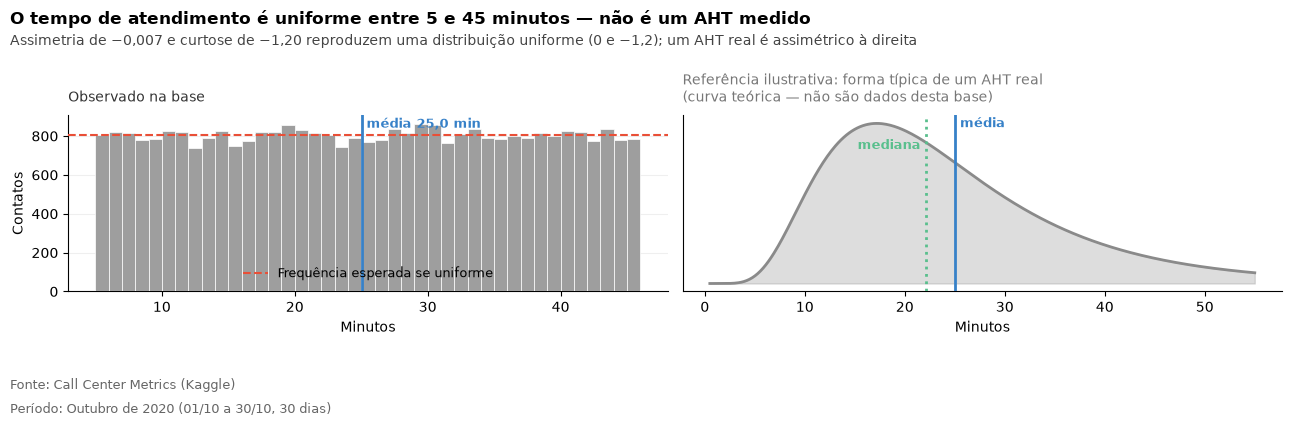

In [26]:
# =========================
# 1. Momentos da distribuição observada
# =========================

aht = df_analise["aht"]

# Referência teórica: uniforme discreta no intervalo observado
a, b = int(aht.min()), int(aht.max())
n_valores = b - a + 1

momentos = pd.DataFrame({
    "observado": [aht.mean(), aht.median(), aht.std(), aht.skew(), aht.kurt()],
    "uniforme_discreta": [
        (a + b) / 2,
        (a + b) / 2,
        np.sqrt((n_valores**2 - 1) / 12),
        0.0,
        -1.2,
    ],
}, index=["média", "mediana", "desvio_padrão", "assimetria", "curtose"])

print(f"DISTRIBUIÇÃO DO TEMPO DE ATENDIMENTO — {aht.nunique()} valores inteiros de {a} a {b} min")
print(tabela_br(momentos.round(3)))

# =========================
# 2. Teste de aderência à uniforme
# =========================

contagem = aht.value_counts().sort_index()
esperado = len(aht) / n_valores
chi2_unif = (((contagem - esperado) ** 2) / esperado).sum()
gl_unif = n_valores - 1
CRITICO_GL40 = 55.76   # qui-quadrado, 5%, 40 graus de liberdade

print()
print(f"Aderência à uniforme: χ² = {num_br(chi2_unif)} (gl = {gl_unif}; crítico a 5% = {num_br(CRITICO_GL40)}) "
      f"-> {'rejeita uniformidade' if chi2_unif > CRITICO_GL40 else 'NÃO rejeita uniformidade'}")
print(f"Contagem por valor: mínimo {contagem.min()}, máximo {contagem.max()}, esperado {esperado:.0f}")

# =========================
# 3. Gráfico: forma observada vs. forma esperada de um AHT real
# =========================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

# --- observado ---
ax1.hist(aht, bins=range(a, b + 2), color="#9E9E9E", edgecolor="white",
         linewidth=0.5, zorder=3)
ax1.axhline(esperado, color="#E94F37", linestyle="--", linewidth=1.5, zorder=4,
            label="Frequência esperada se uniforme")
ax1.axvline(aht.mean(), color="#3781C8", linewidth=2, zorder=4)
ax1.text(aht.mean(), ax1.get_ylim()[1] * 0.93, f" média {aht.mean():.1f} min".replace(".", ","),
         color="#3781C8", fontsize=9, fontweight="bold")
ax1.set_title("Observado na base", fontsize=10, loc="left", color="#333333", pad=10)
ax1.set_xlabel("Minutos")
ax1.set_ylabel("Contatos")
ax1.legend(loc="lower center", frameon=False, fontsize=9)

# --- referência ilustrativa: forma de um AHT real (log-normal) ---
# NÃO são dados desta base: é a curva teórica que um tempo de atendimento
# costuma seguir, desenhada com a mesma média para permitir a comparação visual.
sigma = 0.5
mu = np.log(aht.mean()) - sigma**2 / 2
x = np.linspace(0.5, b + 10, 400)
pdf = 1 / (x * sigma * np.sqrt(2 * np.pi)) * np.exp(-((np.log(x) - mu) ** 2) / (2 * sigma**2))

ax2.fill_between(x, pdf, color="#9E9E9E", alpha=0.35, zorder=3)
ax2.plot(x, pdf, color="#8A8A8A", linewidth=2, zorder=4)
ax2.axvline(np.exp(mu + sigma**2 / 2), color="#3781C8", linewidth=2, zorder=5)
ax2.axvline(np.exp(mu), color="#59BF8D", linewidth=2, linestyle=":", zorder=5)
ax2.text(np.exp(mu + sigma**2 / 2), ax2.get_ylim()[1] * 0.93, " média",
         color="#3781C8", fontsize=9, fontweight="bold")
ax2.text(np.exp(mu), ax2.get_ylim()[1] * 0.80, "mediana ",
         color="#59BF8D", fontsize=9, fontweight="bold", ha="right")
ax2.set_title("Referência ilustrativa: forma típica de um AHT real\n(curva teórica — não são dados desta base)",
              fontsize=10, loc="left", color="#777777", pad=10)
ax2.set_xlabel("Minutos")
ax2.set_yticks([])

# =========================
# 4. Padrão visual
# =========================

estilo_executivo(
    ax1,
    titulo="O tempo de atendimento é uniforme entre 5 e 45 minutos — não é um AHT medido",
    subtitulo=(f"Assimetria de {aht.skew():.3f} e curtose de {aht.kurt():.2f} reproduzem uma distribuição uniforme "
               f"(0 e −1,2); um AHT real é assimétrico à direita").replace("-0.", "−0,").replace("-1.", "−1,"),
    ylabel="Contatos",
    xlabel="Minutos",
    eixos_extra=(ax2,)
)

plt.show()

**A média de 25 minutos esconde que não há distribuição de atendimento aqui.** Os momentos observados reproduzem uma uniforme discreta com precisão quase exata:

| Estatística | Observado | Uniforme discreta [5, 45] |
|---|---|---|
| Média | 25,022 | 25,000 |
| Mediana | 25,000 | 25,000 |
| Desvio-padrão | 11,816 | 11,832 |
| Assimetria | −0,007 | 0 |
| Curtose | −1,197 | −1,200 |

O teste de aderência confirma: χ² = 43,28 com 40 graus de liberdade, contra um crítico de 55,76 a 5%: **não se rejeita a hipótese de uniformidade**. Cada um dos 41 valores inteiros entre 5 e 45 minutos aparece entre 739 e 863 vezes, contra 803 esperados.

**Por que isso é decisivo.** Tempo de atendimento real não é uniforme: a maioria dos contatos se resolve rápido e uma minoria se estende, o que produz uma distribuição **assimétrica à direita**, com média acima da mediana e cauda longa. É exatamente o formato do painel à direita. Aqui, média e mediana coincidem em 25,0 e a assimetria é −0,007: a chance de um atendimento durar 5 minutos é a mesma de durar 45.

Nenhuma operação de atendimento se comporta assim. Confirmando o que a análise por canal já indicava, este campo é um valor sorteado, não um tempo medido.

**Consequência prática.** A métrica não sustenta nenhum uso de dimensionamento.

Isso reforça a conclusão da seção 3.5 por outro caminho: o dado necessário para fechar o diagnóstico de capacidade não está nesta base, e não basta que a coluna exista, ela precisa se comportar como a métrica que o nome promete.

# 4.0 Recomendações

Um déficit agregado tem duas frentes de ação possíveis: aumentar a oferta ou reduzir a demanda. Como a oferta não é mensurável nesta base (não temos dados de headcount ou escala), as recomendações abaixo focam no lado da demanda. São as únicas cujo efeito sobre o volume podemos dimensionar com rigor.


## 4.1 O que não fazer (revisado da Parte 1)

As duas recomendações da seção 2.5 não sobrevivem ao teste feito na Parte 2:

- **Redistribuir contatos entre call centers.** A seção 3.5 mostrou que a diferença entre o melhor e o pior centro é de 0,91pp, não é estatisticamente distinguível de acaso (IC 95% da diferença contém zero) e cobriria, mesmo no cenário mais favorável, menos de um quinto do gap de 4,74pp. Não há base nos dados para esperar melhoria de SLA com essa ação.
- **Reforçar a visibilidade de incidentes de indisponibilidade junto ao time de SRE.** A recomendação partia de indisponibilidade como principal motivador de volume. A seção 3.4 mostrou o oposto: é o menor dos três motivos (14,4%) e **nunca** chega pelo canal de voz. E a aderência por motivo não difere (seção 3.5): contatos de indisponibilidade têm o mesmo SLA que os demais. Reforçar essa visibilidade pode ter mérito por outra razão (dimensionar os canais digitais para picos de incidente, por exemplo), mas não é uma alavanca para o gap de SLA.

## 4.2 O que fazer agora (dimensionado com os dados disponíveis)

- **Desviar dúvidas de fatura para autoatendimento.** É 71,2% do volume, de longe o maior motivo de contato (seção 3.4). Cada 10% desse volume desviado para autoatendimento remove **7,1% do volume total** de contatos. É a alavanca de demanda com o maior efeito dimensionado nesta base. Atenção: o efeito é sobre **volume**. A seção 3.5 não encontrou relação entre volume diário e aderência (r = −0,215), então o ganho em SLA só se confirmaria se a operação estiver de fato limitada por capacidade, o que esta base não permite verificar (seção 5.3). A ação se justifica pelo custo de atendimento; o efeito no SLA precisa ser medido depois da implantação.
- **Tratar pagamento como ponto único de falha do canal de voz.** Pagamento entra 100% por telefone e por nenhum outro canal (seção 3.4). Qualquer indisponibilidade do canal telefônico interrompe integralmente esse fluxo, sem caminho alternativo, vale um plano de contingência específico para ele.

# 5.0 Conclusão

A Parte 2 testou sistematicamente as quatro afirmações centrais listadas na abertura da seção 3.0. Nenhuma sobrevive. O que resta, e o que não é possível afirmar, organiza-se em três camadas, seguidas do que essa revisão me ensinou (seção 5.4).

## 5.1 O que a operação mostra

A aderência ao SLA em outubro de 2020 foi de **75,3%**, um gap de **4,7pp** até a meta de 80%. Esse gap é de **patamar, não de evento**: a variação diária cabe quase inteiramente dentro do ruído amostral: 29 dos 30 dias caem na faixa esperada por acaso (seção 3.3).

Nenhuma dimensão disponível o explica. Call center (χ² = 3,36), canal (χ² = 2,10), motivo (χ² = 2,86) e dia da semana (χ² = 5,46): nenhum resultado é significativo a 5% (seção 3.5). O centro de maior volume, Los Angeles, registra a **maior** aderência, não a menor, o oposto do que a hipótese de sobrecarga da Parte 1 previa.

O desempenho operacional também não se traduz em experiência do cliente (seção 3.6): o CSAT é estatisticamente idêntico entre contatos dentro e fora do SLA, e a diferença sequer tem a direção esperada.

A demanda, por outro lado, tem estrutura real e localizável (seção 3.4): 71,2% do volume é dúvida de fatura, roteada por todos os canais; indisponibilidade (apontada na Parte 1 como principal motivador) é o menor dos três motivos e nunca chega por voz.

## 5.2 O que a base não permite

Vários campos não se comportam como as métricas que nomeiam. O tempo de atendimento é uma distribuição uniforme discreta entre 5 e 45 minutos (seção 3.7), não um AHT medido. O volume diário varia apenas 3% (coeficiente de variação). Nenhuma dimensão testada correlaciona com o SLA.

E faltam colunas inteiras: não há agente, headcount ou escala, e todo registro de horário está fixado em 00:00:00: não há granularidade intraday.

## 5.3 O teto do diagnóstico

Um déficit uniforme em todas as dimensões, em uma operação real, apontaria para uma restrição agregada de capacidade: a operação está subdimensionada. 

O problema é que esta base não nos permite afirmar isso com segurança. A evidência de que os dados são majoritariamente sintéticos (como o AHT perfeitamente uniforme) nos impede de bater o martelo. Insistir nisso seria repetir o erro da Parte 1: tirar conclusões além do que os dados provam.

Por isso, o diagnóstico mais honesto aqui não é uma resposta final, mas sim o mapeamento das limitações dos dados atuais e o entendimento de que um novo levantamento seria necessário.


## 5.4 Considerações Finais e O que eu aprendi

O que mudou entre o João que escreveu a Parte 1 e o João da Parte 2?

**Testar uma hipótese, não só ilustrá-la:** Aprendi que validar uma hipótese é tão importante quanto ilustrar. Usei o teste qui-quadrado de independência (seção 3.5), intervalo de confiança de 95% e aprendi a usar o **t de Student** quando a amostra é pequena (seção 3.5).

**Ter um método, não só uma técnica:** A Parte 1 faltava método científico. A Parte 2 foi diferente: declarei as hipóteses **antes** de testá-las, buscando confirmar ou derrubar cada uma, em vez de criar narrativas em cima de gráficos soltos.
**Vocabulário e WFM:** Entrei neste projeto sem conhecer os principais conceitos de Workforce Management. Ao longo da análise, aprendi termos como **AHT** (tempo médio de atendimento), **nível de serviço - SLA (citação especial para esse, dado que é um conceito comum em SRE)**, CSAT Score (Customer Satisfaction Score)... entre outros. 

Esse vocabulário é essencial para interpretar os dados e fazer as perguntas certas sobre uma operação de atendimento.



# Créditos

- [LinkedIn — jvroot](https://www.linkedin.com/in/jvroot/)
- [GitHub — JV-root](https://github.com/JV-root)

Obrigado por chegar até aqui. Se quiser ver outros projetos ou trocar uma ideia, me encontra no LinkedIn ou no GitHub.